In [6]:
import numpy as np
from scipy import signal
import utils
import pandas as pd

path = r'Cross_validation/for_data/flatten_older_/LSTM_k='
k_record = [pd.read_pickle(path+str(k)+'_record.pkl') for k in range(5)]

record=k_record[0]
print(record.keys())

Index(['name', 'input', 'pred', 'label', 'fs_signal'], dtype='object')


In [9]:
k_csv = [pd.read_csv(path+str(k)+'_static.csv') for k in range(5)]
csv=k_csv[0]
print(csv.keys())

Index(['Unnamed: 0', 'name', 'e_hr', 'e_b2b', 'e_BBI', 'HR_p', 'HR_B2B_p',
       'BBI_p', 'peaks_p', 'HR_l', 'HR_B2B_l', 'BBI_l', 'peaks_l', 'HR_f',
       'HR_B2B_f', 'BBI_f', 'peaks_f'],
      dtype='object')


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import  ConnectionPatch
from matplotlib.patches import Rectangle
def plt_plot(*args, **kwargs):
    def figure_para(ax, dic, i):
        
        ax.set_title(dic['title'],fontweight='bold') if 'title' in dic else None

        ax.text(0.01, 0.95, f'({chr(97+i)})', transform=ax.transAxes, va='top') if 'text' in dic else None

        ax.set_xlim(dic['xlim'][0], dic['xlim'][1]) if 'xlim' in dic else None

        ax.set_ylim(dic['ylim'][0], dic['ylim'][1]) if 'ylim' in dic else None

        ax.set_xlabel(dic['xlabel'],fontweight='bold') if 'xlabel' in dic else None

        ax.set_ylabel(dic['ylabel'],fontweight='bold') if 'ylabel' in dic else None
        
    def x_y(dic):

        # 保证y为list
        ys = [dic['y']] if not isinstance(dic['y'], list) else dic['y']
        # 保证x存在
        x = dic.get('x', np.array(range(len(ys[0]))))
        # 保证ls存在         
        ls = dic.get('l', dic.get('label', [None] * len(dic['y'])))
        ls = [ls] if not isinstance(ls, list) else ls
        # 保证linewidth存在
        lws = dic.get('linewidth', dic.get('lw', [2] * len(dic['y'])))
        lws = [lws] if not isinstance(lws, list) else lws
        # 保证cs存在    
        cs = dic.get('color', dic.get('c', [None] * len(dic['y'])))
        cs = [cs] if not isinstance(cs, list) else cs
        # 保证cs存在    
        cs = dic.get('color', dic.get('c', [None] * len(dic['y'])))
        cs = [cs] if not isinstance(cs, list) else cs
        # 保证alphas存在 
        alphas = dic.get('alpha', dic.get('a', [1] * len(dic['y'])))
        alphas = [alphas] if not isinstance(alphas, list) else alphas
        return [x, ys, ls, lws, cs, alphas]

    def figure_main(ax, dic, para_list, **kwargs):
        # 绘制多条曲线
        [x, ys, ls, lws, cs, alphas] = para_list
        [ax.plot(x, y, label=l, linewidth=lw, color=c, alpha=alpha) if l else ax.plot(x, y, label=l, linewidth=lw, color=c, alpha=alpha) for y, l, lw, c, alpha in zip(ys, ls, lws, cs, alphas)]
        ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
        # ax.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, fontsize=kwargs.get('legend_fontsize', 12)-4)
        # 绘制多条曲线点
        if 'points' in dic:
            ps = [dic['points']['p']] if not isinstance(dic['points']['p'], list) else dic['points']['p']
            pcs = dic['points'].get('color', dic['points'].get('c', ['red'] * len(ps)))
            pls = dic['points'].get('linewidth', dic['points'].get('lw', [1] * len(ps)))
            for y, p, pl, pc in zip(ys[:len(ps)], ps, pls, pcs):
                ax.scatter(x[p], y[p], linewidth=pl, color=pc)

            
        if 'hide' in dic:
            ax.set_xticks([]) if 'xticks' in dic['hide'] else None
            ax.set_xticklabels([]) if 'xticks' in dic['hide'] else None

            ax.set_yticks([]) if 'yticks' in dic['hide'] else None
            ax.set_yticklabels([]) if 'yticks' in dic['hide'] else None
            
            ax.spines['top'].set_color('none') if 'top' in dic['hide'] or 't' in dic['hide'] else None

            ax.spines['bottom'].set_color('none') if 'bottom' in dic['hide'] or 'b' in dic['hide'] else None

            ax.spines['left'].set_color('none') if 'left' in dic['hide'] or 'l' in dic['hide'] else None

            ax.spines['right'].set_color('none') if 'right' in dic['hide'] or 'r' in dic['hide'] else None
        
        # 打开网格线
        if 'grid' in dic:
            x_major_ticks_top = np.arange(np.min(x),np.max(x)+2,2)
            y_major_ticks_top = np.arange(np.min(ys),np.max(ys)+2,2)
            ax.set_xticks(x_major_ticks_top, minor=False)
            ax.set_yticks(y_major_ticks_top, minor=False)
            ax.grid(which="major", alpha=0.8,linestyle='dashed')
            
            x_minor_ticks_top = np.arange(np.min(x),np.max(x)+1,1)
            y_minor_ticks_top = np.arange(np.min(ys),np.max(ys)+2,1)
            ax.set_xticks(x_minor_ticks_top, minor=True)
            ax.set_yticks(y_minor_ticks_top, minor=True)
            ax.grid(which="minor", alpha=0.4, linestyle='dashed')
        
        # 绘制多条垂直虚线
        if 'vlines' in dic:
            vlines_linewidth = dic['vlines'].get('linewidth', dic['vlines'].get('lw', 1))
            vlines_color = dic['vlines'].get('color', dic['vlines'].get('c', 'red'))
            ymin, ymax = dic['vlines'].get('y', (ax.get_ylim()))
            ax.vlines(x[dic['vlines']['v']], ymin, ymax, colors=vlines_color, linestyles='dashed', linewidth=vlines_linewidth)
        # 创建一个方框，指定左上角的坐标、宽度和高度
        if 'rectangle' in dic:
            lw = dic['rectangle'].get('linewidth', dic['rectangle'].get('lw', 1))
            c = dic['rectangle'].get('color', dic['rectangle'].get('c', 'red'))
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            h = dic['rectangle'].get('h', ymax-ymin)
            w = dic['rectangle'].get('w', xmax-xmin)
            px = dic['rectangle'].get('px', xmin)
            py = dic['rectangle'].get('py', ymin)
            # h_lim = ymax-ymin + dic['rectangle'].get('h_lim') 
            # w_lim = xmax-xmin + dic['rectangle'].get('w_lim')
            # px_lim = xmin + dic['rectangle'].get('px_lim')
            # py_lim = ymin + dic['rectangle'].get('py_lim')
            ax.add_patch(Rectangle((px, py), w, h, fill=False, color=c, linestyle='dashed', linewidth=lw))

    def zone_and_linked(ax,axins,zone_left,zone_right,x,y,linked='bottom',
                        x_ratio=0.05,y_ratio=0.05):
        """缩放内嵌图形，并且进行连线
        ax:         调用plt.subplots返回的画布。例如: fig,ax = plt.subplots(1,1)
        axins:      内嵌图的画布。 例如 axins = ax.inset_axes((0.4,0.1,0.4,0.3))
        zone_left:  要放大区域的横坐标左端点
        zone_right: 要放大区域的横坐标右端点
        x:          X轴标签
        y:          列表,所有y值
        linked:     进行连线的位置，{'bottom','top','left','right'}
        x_ratio:    X轴缩放比例
        y_ratio:    Y轴缩放比例
        """
        xlim_left = x[zone_left]-(x[zone_right]-x[zone_left])*x_ratio
        xlim_right = x[zone_right]+(x[zone_right]-x[zone_left])*x_ratio

        y_data = np.hstack([yi[zone_left:zone_right] for yi in y])
        ylim_bottom = np.min(y_data)-(np.max(y_data)-np.min(y_data))*y_ratio
        ylim_top = np.max(y_data)+(np.max(y_data)-np.min(y_data))*y_ratio

        axins.set_xlim(xlim_left, xlim_right)
        axins.set_ylim(ylim_bottom, ylim_top)

        ax.plot([xlim_left,xlim_right,xlim_right,xlim_left,xlim_left],
                [ylim_bottom,ylim_bottom,ylim_top,ylim_top,ylim_bottom],"black")

        if linked == 'bottom':
            xyA_1, xyB_1 = (xlim_left,ylim_top), (xlim_left,ylim_bottom)
            xyA_2, xyB_2 = (xlim_right,ylim_top), (xlim_right,ylim_bottom)
        elif  linked == 'top':
            xyA_1, xyB_1 = (xlim_left,ylim_bottom), (xlim_left,ylim_top)
            xyA_2, xyB_2 = (xlim_right,ylim_bottom), (xlim_right,ylim_top)
        elif  linked == 'left':
            xyA_1, xyB_1 = (xlim_right,ylim_top), (xlim_left,ylim_top)
            xyA_2, xyB_2 = (xlim_right,ylim_bottom), (xlim_left,ylim_bottom)
        elif  linked == 'right':
            xyA_1, xyB_1 = (xlim_left,ylim_top), (xlim_right,ylim_top)
            xyA_2, xyB_2 = (xlim_left,ylim_bottom), (xlim_right,ylim_bottom)
            
        con = ConnectionPatch(xyA=xyA_1,xyB=xyB_1,coordsA="data",
                            coordsB="data",axesA=axins,axesB=ax)
        axins.add_artist(con)
        con = ConnectionPatch(xyA=xyA_2,xyB=xyB_2,coordsA="data",
                            coordsB="data",axesA=axins,axesB=ax)
        axins.add_artist(con)

    def fig_save(fig, n, **kwargs):     
        if kwargs.get('savepath', False):
            fig.savefig(kwargs.get('savepath', False), dpi=kwargs.get('dpi', 500), bbox_inches='tight')
        if kwargs.get('save_path', False):
            fig.savefig(kwargs.get('save_path', False), dpi=kwargs.get('dpi', 500), bbox_inches='tight')
        # Show the plot
        if kwargs.get('show', True):
            plt.show()
            
    # res提取
    res = [arg for arg in args]
    n = len(res)
    
    # fig初始化
    plt.rcParams['font.size'] = kwargs.get('fontsize', 16)
    plt.rcParams['font.family'] = kwargs.get('fontfamily', 'Times New Roman')
    plt.rcParams['font.weight'] = kwargs.get('fontweight', 'bold')
    fig, axs = plt.subplots(n, 1, dpi=kwargs.get('dpi', 500), figsize=kwargs.get('figsize', (10, 2*n)), 
                            sharex=kwargs.get('sharex', False), squeeze=kwargs.get('squeeze', False))
    fig.subplots_adjust(hspace=kwargs.get('hspace', 0))
    fig.suptitle(kwargs.get('suptitle', None))
    
    # 多子图
    for i in range(n):
        dic = res[i]
        #define axs[i] axi
        if type(dic) == dict:
            # 图像参数初始化
            figure_para(axs[i, 0], dic, i)
            # 一图多线下确保形状一致
            para_list = x_y(dic)
            # 图像主图
            figure_main(axs[i, 0], dic, para_list, **kwargs)
            if 'in' in dic.keys(): 
                # 绘制缩放图
                axins = axs[i, 0].inset_axes(dic['in']['inset'])
                # # 缩放图参数初始化
                figure_para(axins, dic['in'], i)
                # 在缩放图中也绘制主图所有内容，然后根据限制横纵坐标来达成局部显示的目的
                figure_main(axins, dic, para_list, **kwargs)
                # 局部显示并且进行连线
                x = para_list[0]
                ys = para_list[1]
                zone_and_linked(axs[i, 0], axins, dic['in']['section'][0], dic['in']['section'][1], x , ys, dic['in'].get('location', 'right'))
        else:
            axs[i, 0].plot(dic, linewidth=2)
    # fig存储和调整
    fig_save(fig,n, **kwargs)
    # Show the plot
    if kwargs.get('show', False):
        plt.show()



/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


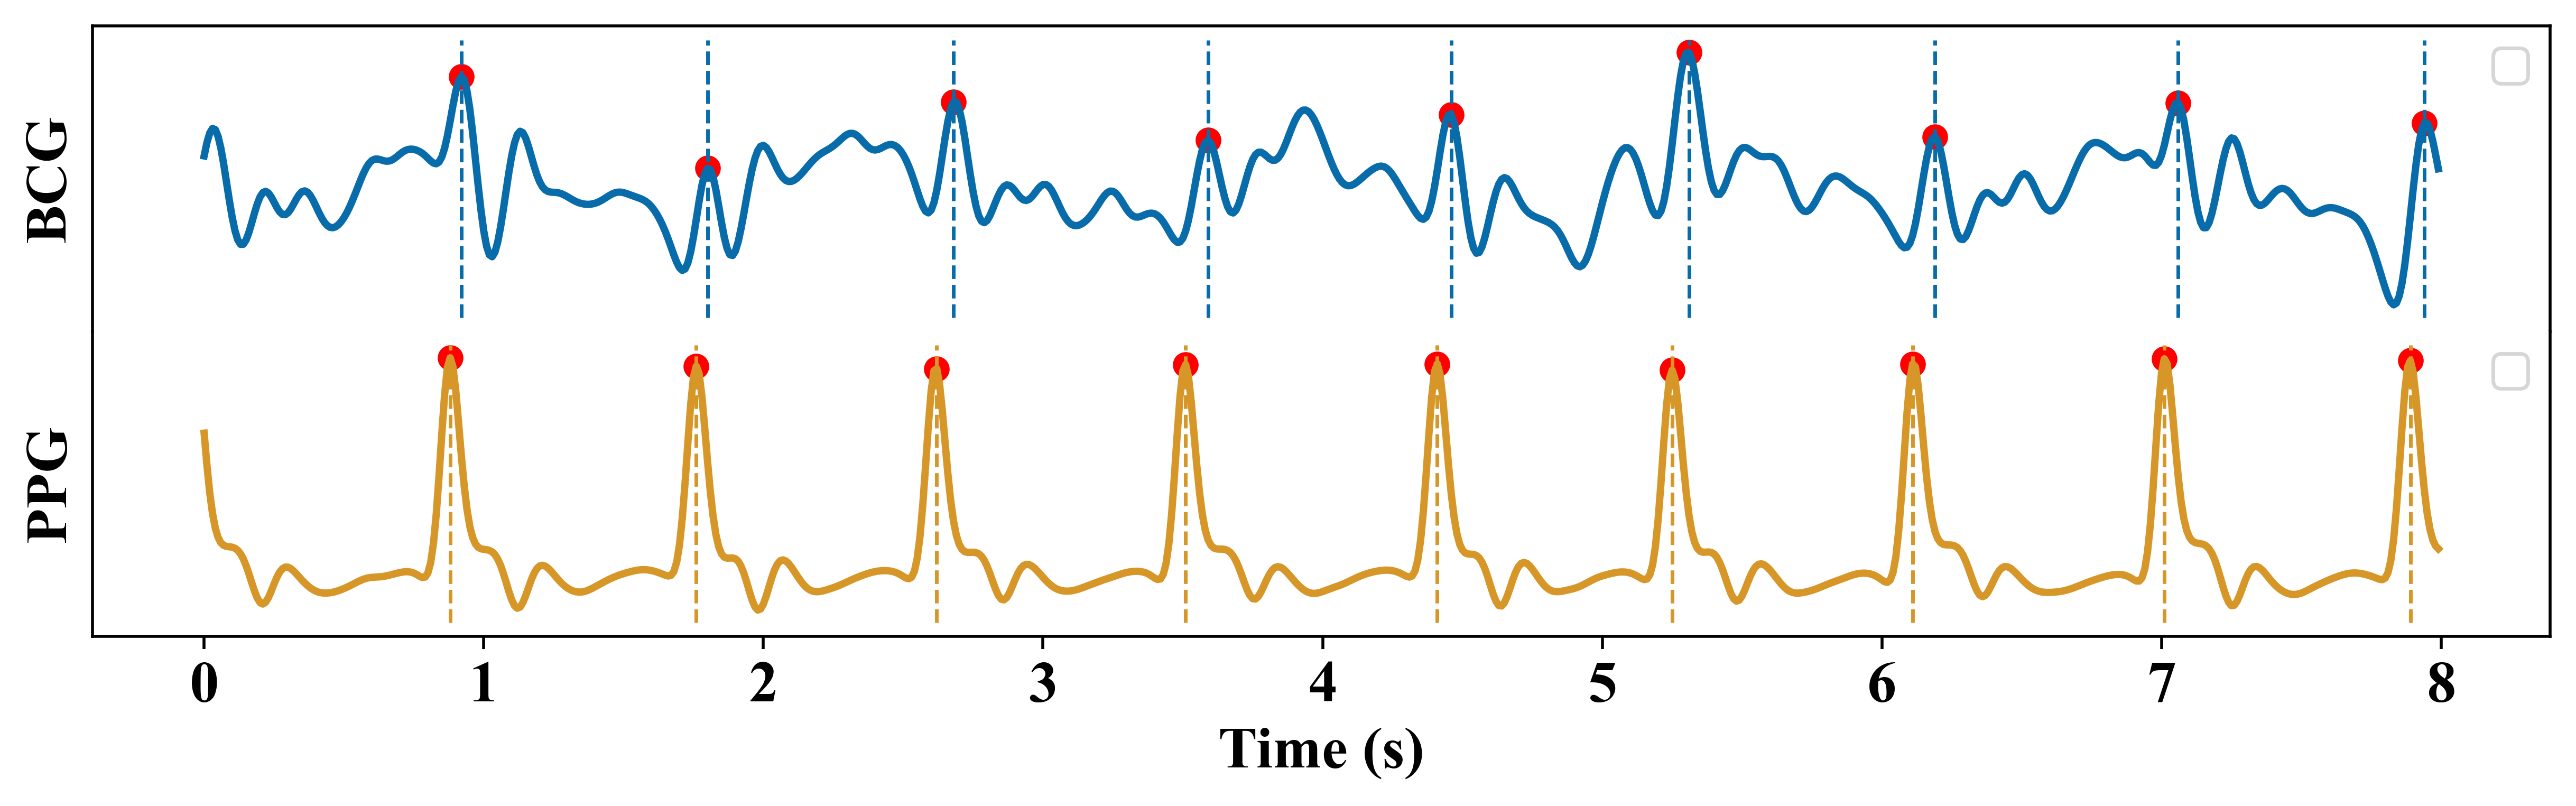

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


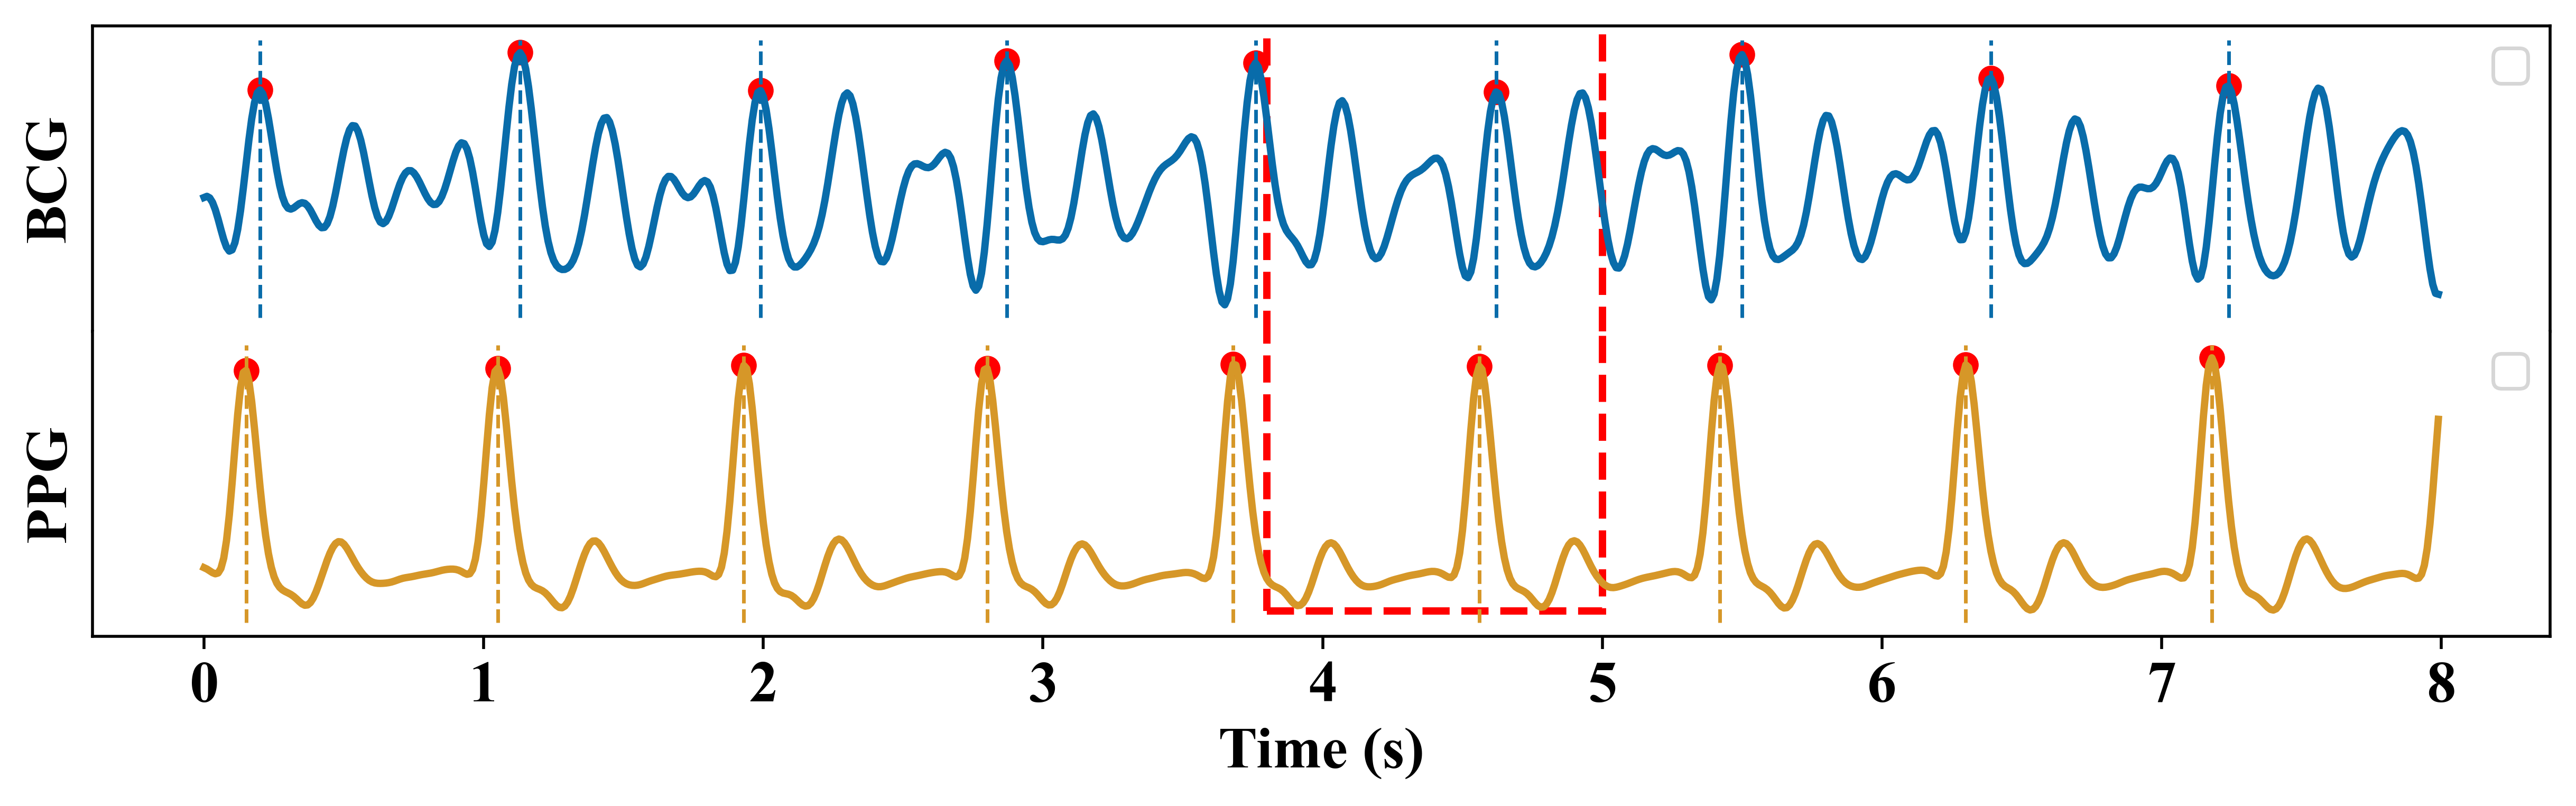

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


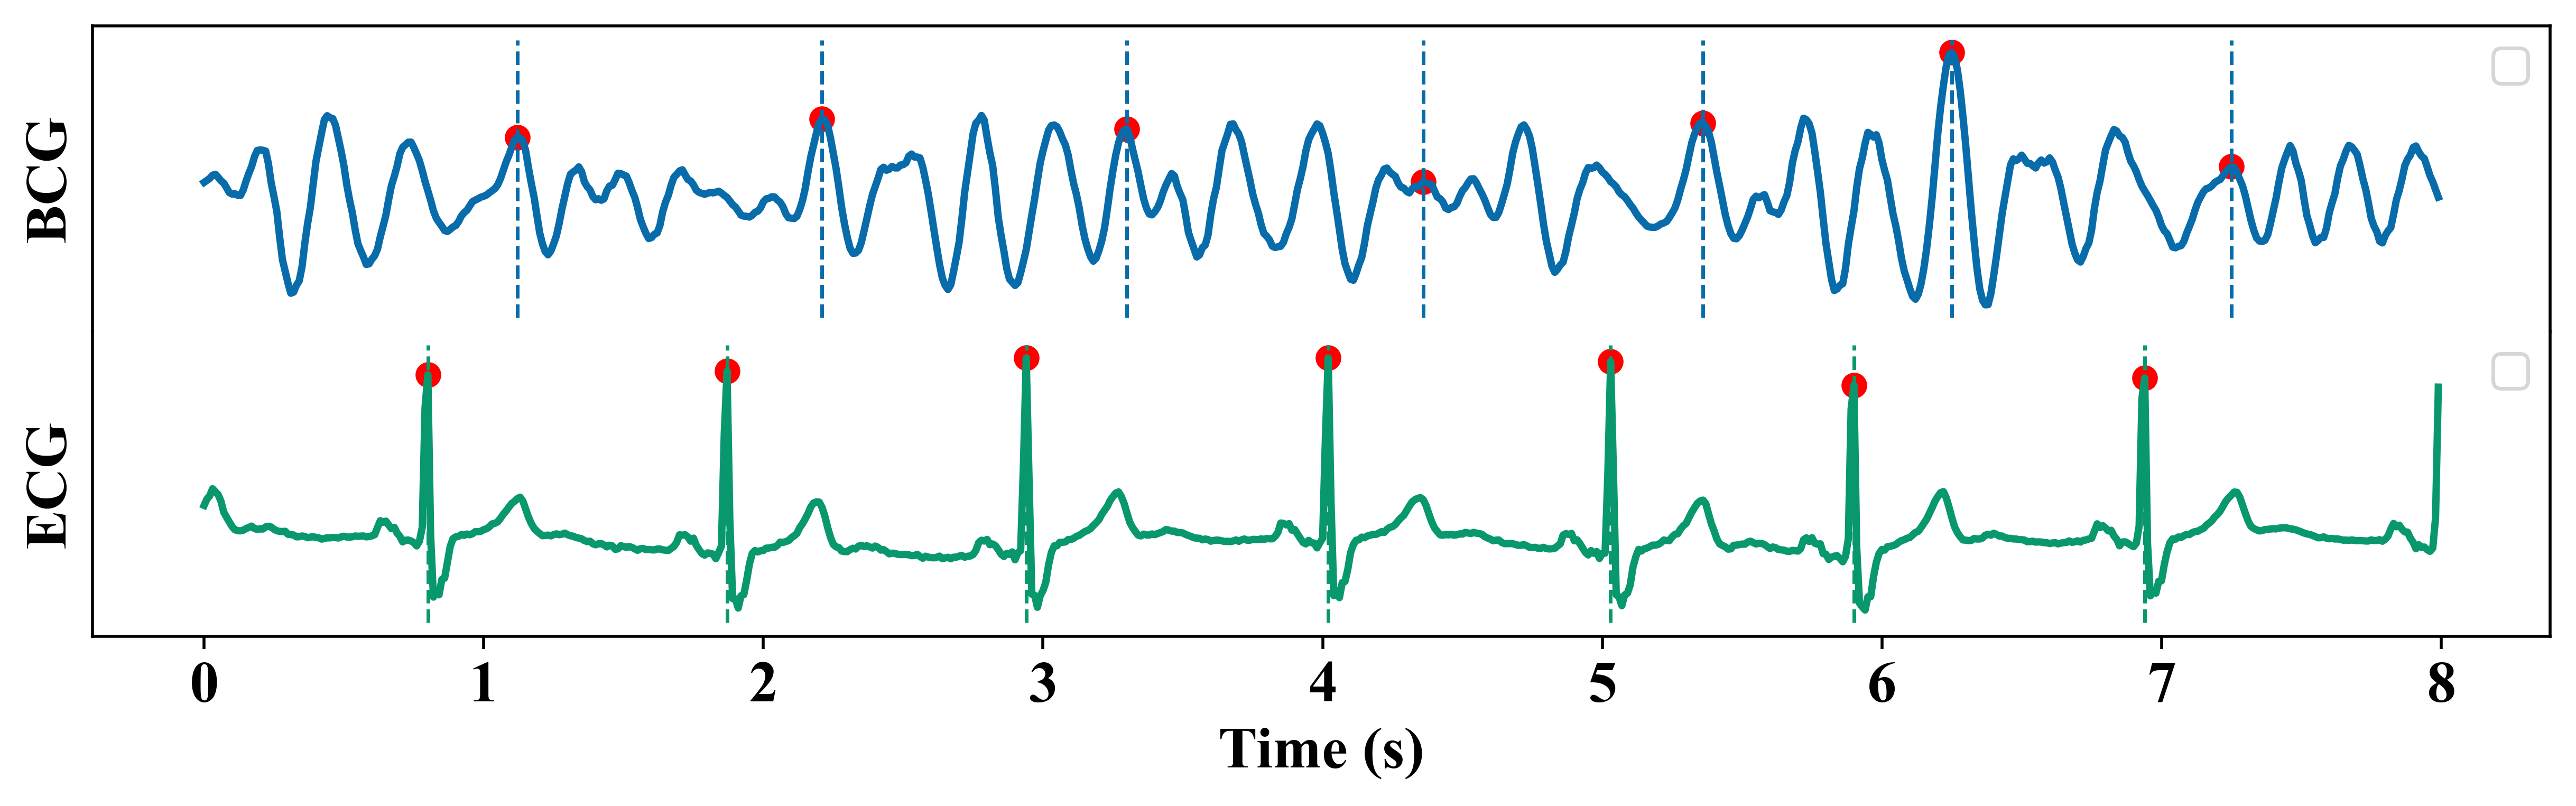

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58434/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


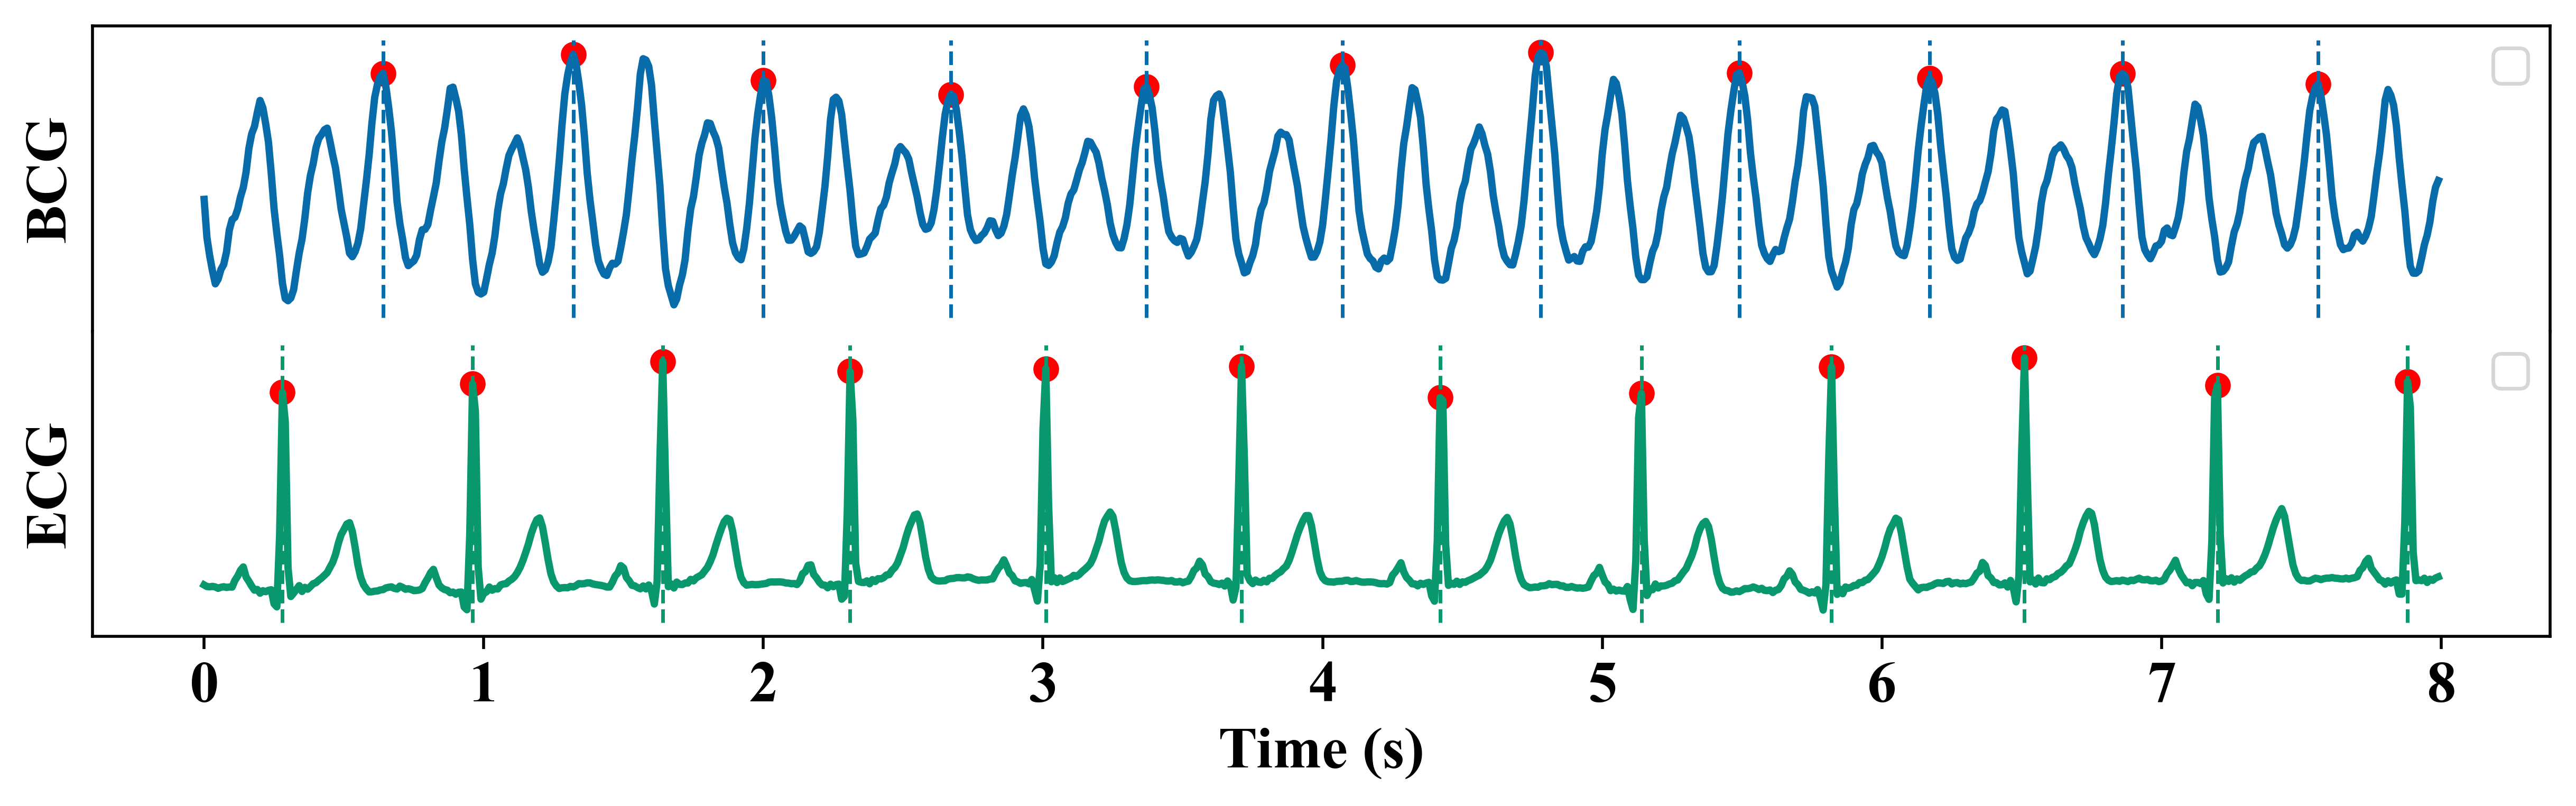

In [2]:
import numpy as np
from scipy import signal
import utils
import pandas as pd

path = r'Cross_validation/for_data/flatten_older_/LSTM_k='
k_record = [pd.read_pickle(path+str(k)+'_record.pkl') for k in range(5)]

k = 4
s = 1000
e = 1800
record = k_record[0]
flag_y = 0
flag_o = 0
for enu, (name, input, pred, label, fs_signal) in enumerate(zip(record['name'], record['input'], record['pred'], record['label'], record['fs_signal'])): 

    if enu == 6: # 1054
        pred      = pred[s:e]
        label     = label[s:e]
        input     = input[s:e]
        fs_signal = fs_signal[s:e]
        
        input = np.load(r"data_label/data_fusion/flatten/"+name+".npy")[s:e]
        # savepath = r"picture\res\\" + name
        
        input = utils.Z_ScoreNormalization(input)
        p_input = signal.find_peaks(input, distance=20, prominence=1,wlen=10)[0]
        
        fs_signal = utils.Z_ScoreNormalization(fs_signal)
        p_fs = signal.find_peaks(fs_signal, height=0.1, distance=60)[0]
        
        plt_plot(
                {
                'x':np.arange(e-s)/100, 'y':input, 'ylabel':'BCG','c':'#096caa',   
                'points':{'p':p_input, 'c':'red'}, 
                'vlines':{'v':p_input, 'c':"#096caa", 'lw':1},
                'hide':{'xticks':True, 'yticks':True, 'b': True},
                # 'rectangle':{'px':0.5,'py':-5, 'w':1.5 ,'h':10.3, 'lw':2}
                },
                {
                'x':np.arange(e-s)/100, 'y':fs_signal, 'xlabel':"Time (s)", 'ylabel':'PPG', 'c':'#d69728',
                'points':{'p':p_fs, 'c':'red'},
                'vlines':{'v':p_fs, 'c':"#d69728", 'lw':1},
                'hide':{'yticks':True, 't': True},
                # 'rectangle':{'px':0.5,'py':-1.5, 'w':1.5 ,'h':10, 'lw':2}
                },
                # suptitle = f'Young subject Example {flag_y}',
                show=True, figsize=(12, 3), linewidth=2
                )
    if enu == 35:
        pred      = pred[s:e]
        label     = label[s:e]
        input     = input[s:e]
        fs_signal = fs_signal[s:e]
        
        input = np.load(r"data_label/data_fusion/flatten/"+name+".npy")[s:e]
        # savepath = r"picture\res\\" + name
        
        input = utils.Z_ScoreNormalization(input)
        p_input = signal.find_peaks(input, distance=50, prominence=2,wlen=20)[0]
        
        fs_signal = utils.Z_ScoreNormalization(fs_signal)
        p_fs = signal.find_peaks(fs_signal, height=0.1, distance=60)[0]
        
        plt_plot(
                {
                'x':np.arange(e-s)/100, 'y':input, 'ylabel':'BCG','c':'#096caa',   
                'points':{'p':p_input, 'c':'red'}, 
                'vlines':{'v':p_input, 'c':"#096caa", 'lw':1},
                'hide':{'xticks':True, 'yticks':True, 'b': True},
                'rectangle':{'px':3.8,'py':-5, 'w':1.2 ,'h':9, 'lw':2}
                },
                {
                'x':np.arange(e-s)/100, 'y':fs_signal, 'xlabel':"Time (s)", 'ylabel':'PPG', 'c':'#d69728',
                'points':{'p':p_fs, 'c':'red'},
                'vlines':{'v':p_fs, 'c':"#d69728", 'lw':1},
                'hide':{'yticks':True, 't': True},
                'rectangle':{'px':3.8,'py':-1, 'w':1.2 ,'h':10, 'lw':2}
                },
                # suptitle = f'Young subject Example {flag_y}',
                show=True, figsize=(12, 3), linewidth=2
                )
        flag_y += 1

    s = 0
    e = 800
    if enu  in  [42]: # 1054

        pred      = pred[s:e]
        label     = label[s:e]
        input     = input[s:e]
        fs_signal = fs_signal[s:e]
        
        input = np.load(r"data_label/data_fusion/older/"+name+".npy")[s:e]
        # savepath = r"picture\res\\" + name
        
        input = utils.Z_ScoreNormalization(input)
        p_input = signal.find_peaks(input, distance=10, prominence=0.1,wlen=20)[0][[4,9,13,18,22,26,30]]
        
        fs_signal = utils.Z_ScoreNormalization(fs_signal)
        p_fs = signal.find_peaks(fs_signal, prominence=1, distance=50)[0]
        
        plt_plot(
                {
                'x':np.arange(e-s)/100, 'y':input, 'ylabel':'BCG', 'c':'#096caa',
                'points':{'p':p_input, 'c':'red'},
                'vlines':{'v':p_input, 'c':"#096caa", 'lw':1},
                'hide':{'xticks':True, 'yticks':True, 'b': True},
                },
                {
                'x':np.arange(e-s)/100, 'y':fs_signal, 'xlabel':"Time (s)", 'ylabel':'ECG', 'c':'#09986e',
                'points':{'p':p_fs, 'c':'red'},
                'vlines':{'v':p_fs, 'c':"#09986e", 'lw':1},
                'hide':{'yticks':True, 't': True},
                },
                # suptitle = f'Elderly subject Example {flag_o}', 
                show=True, figsize=(12, 3), linewidth=2
                )
    
    s = 1100
    e = 1900
    if enu  in  [43]: # 1054

        pred      = pred[s:e]
        label     = label[s:e]
        input     = input[s:e]
        fs_signal = fs_signal[s:e]
        
        input = np.load(r"data_label/data_fusion/older/"+name+".npy")[s:e]
        # savepath = r"picture\res\\" + name
        
        input = utils.Z_ScoreNormalization(input)
        p_input = signal.find_peaks(input, distance=50, prominence=1,wlen=20)[0]
        
        fs_signal = utils.Z_ScoreNormalization(fs_signal)
        p_fs = signal.find_peaks(fs_signal, prominence=1, distance=50)[0]
        
        plt_plot(
                {
                'x':np.arange(e-s)/100, 'y':input, 'ylabel':'BCG', 'c':'#096caa',
                'points':{'p':p_input, 'c':'red'},
                'vlines':{'v':p_input, 'c':"#096caa", 'lw':1},
                'hide':{'xticks':True, 'yticks':True, 'b': True},
                },
                {
                'x':np.arange(e-s)/100, 'y':fs_signal, 'xlabel':"Time (s)", 'ylabel':'ECG', 'c':'#09986e',
                'points':{'p':p_fs, 'c':'red'},
                'vlines':{'v':p_fs, 'c':"#09986e", 'lw':1},
                'hide':{'yticks':True, 't': True},
                },
                # suptitle = f'Elderly subject Example {flag_o}', 
                show=True, figsize=(12, 3), linewidth=2
                )

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


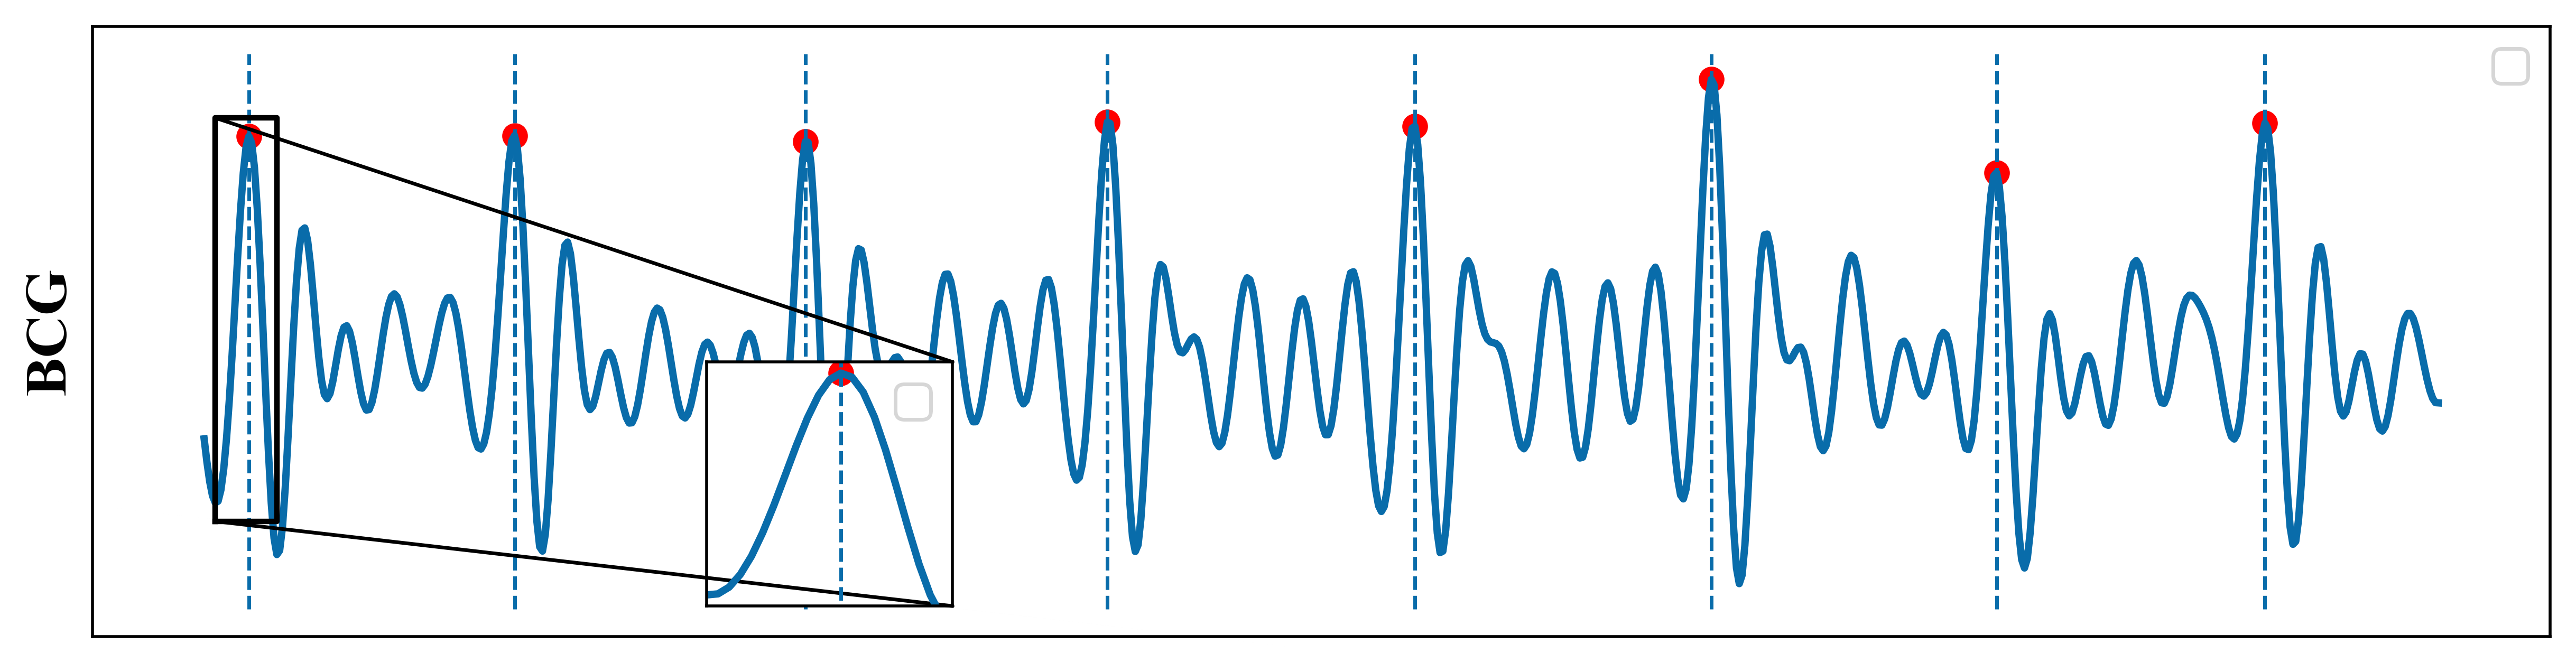

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


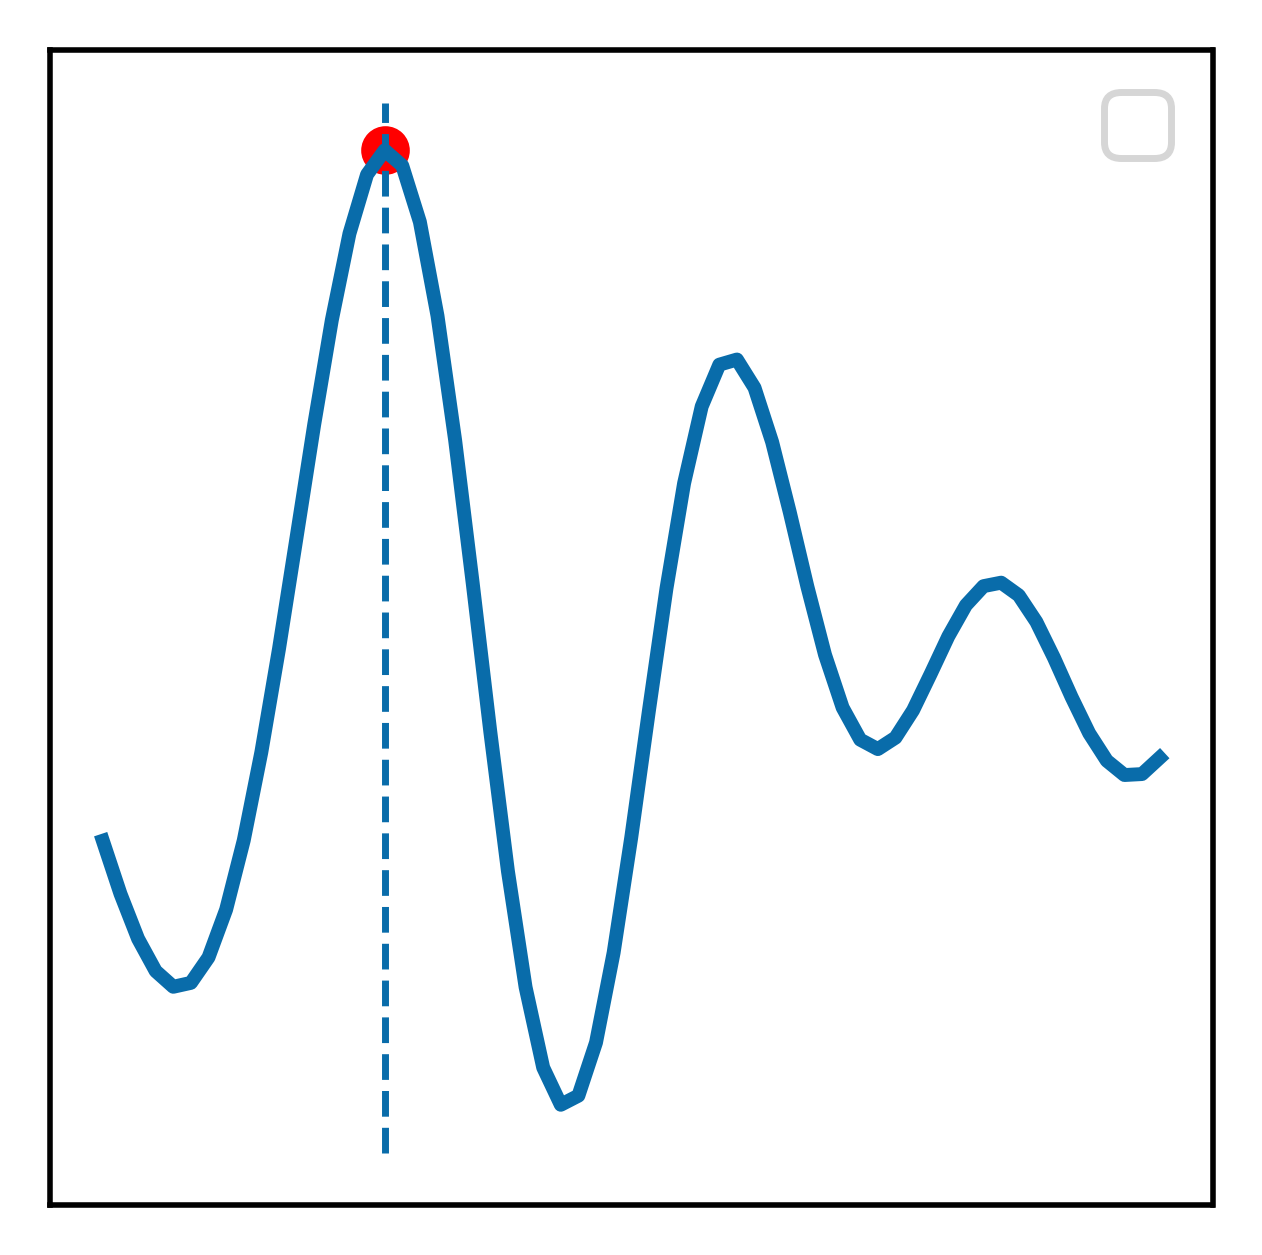

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


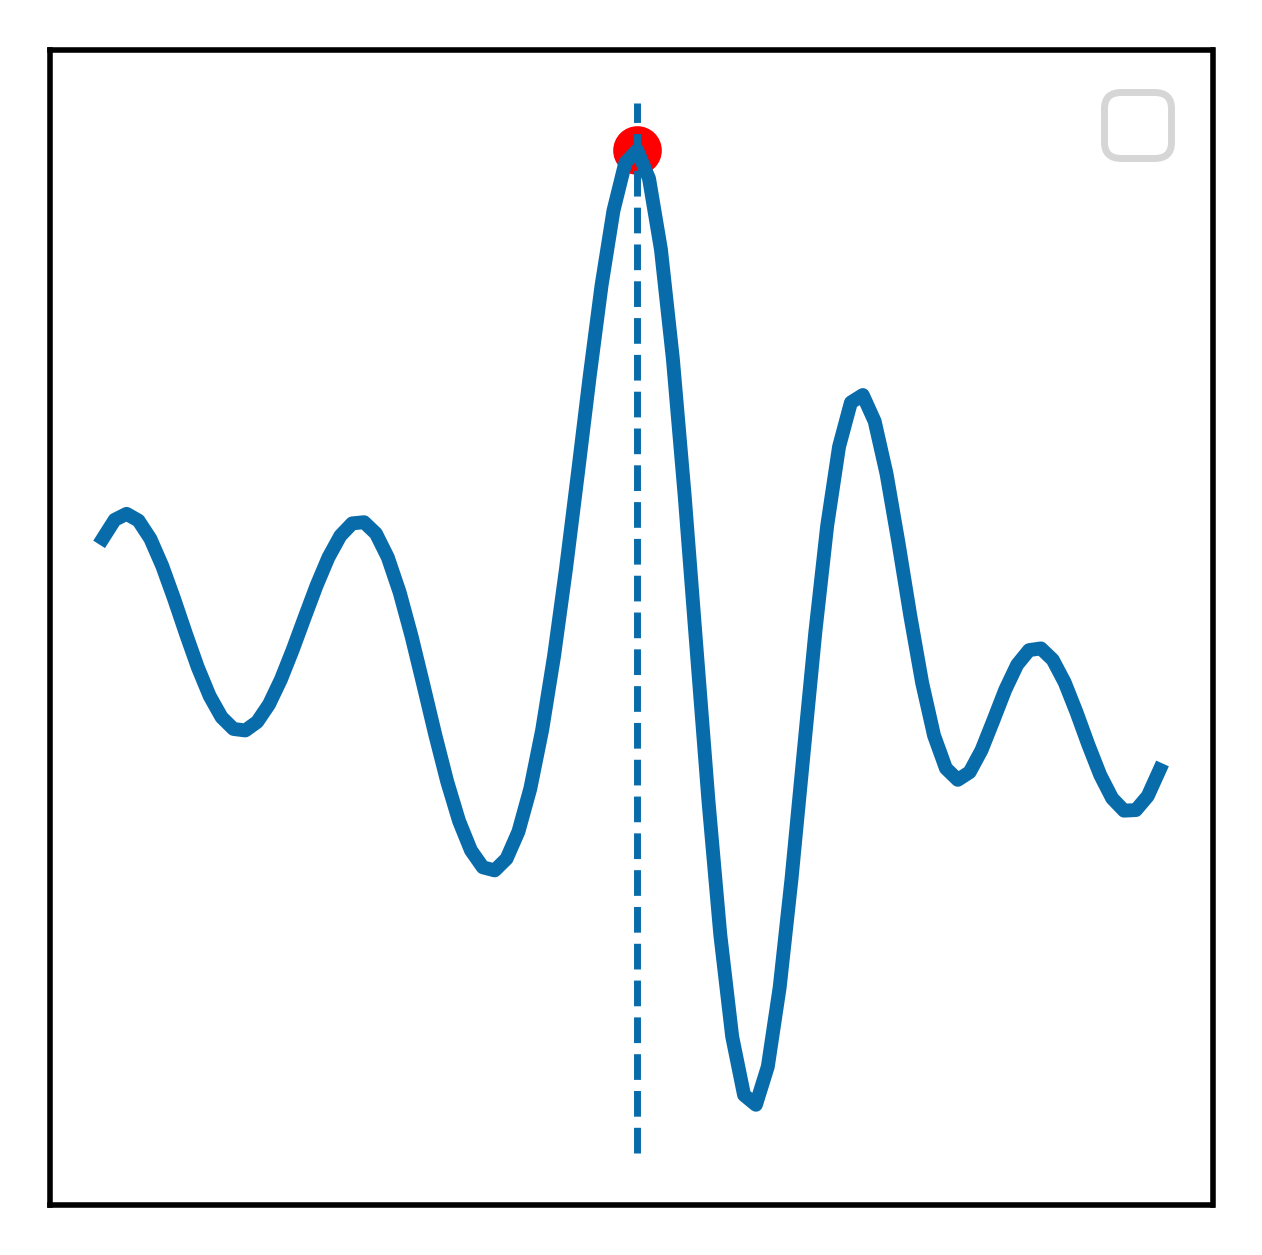

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


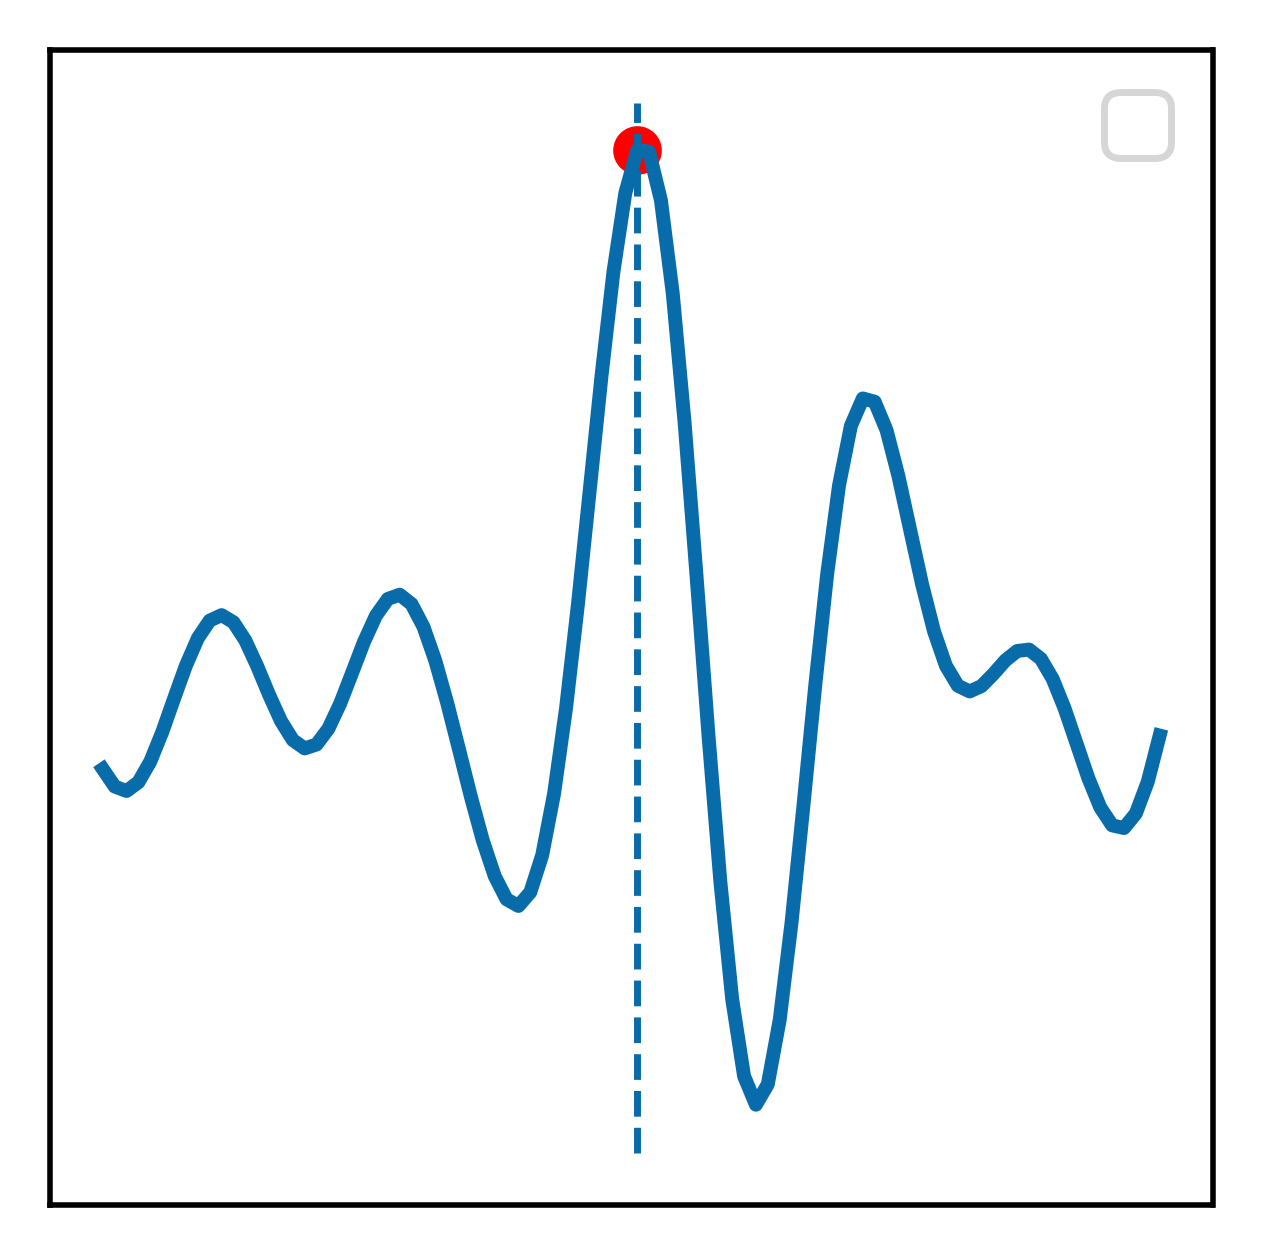

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


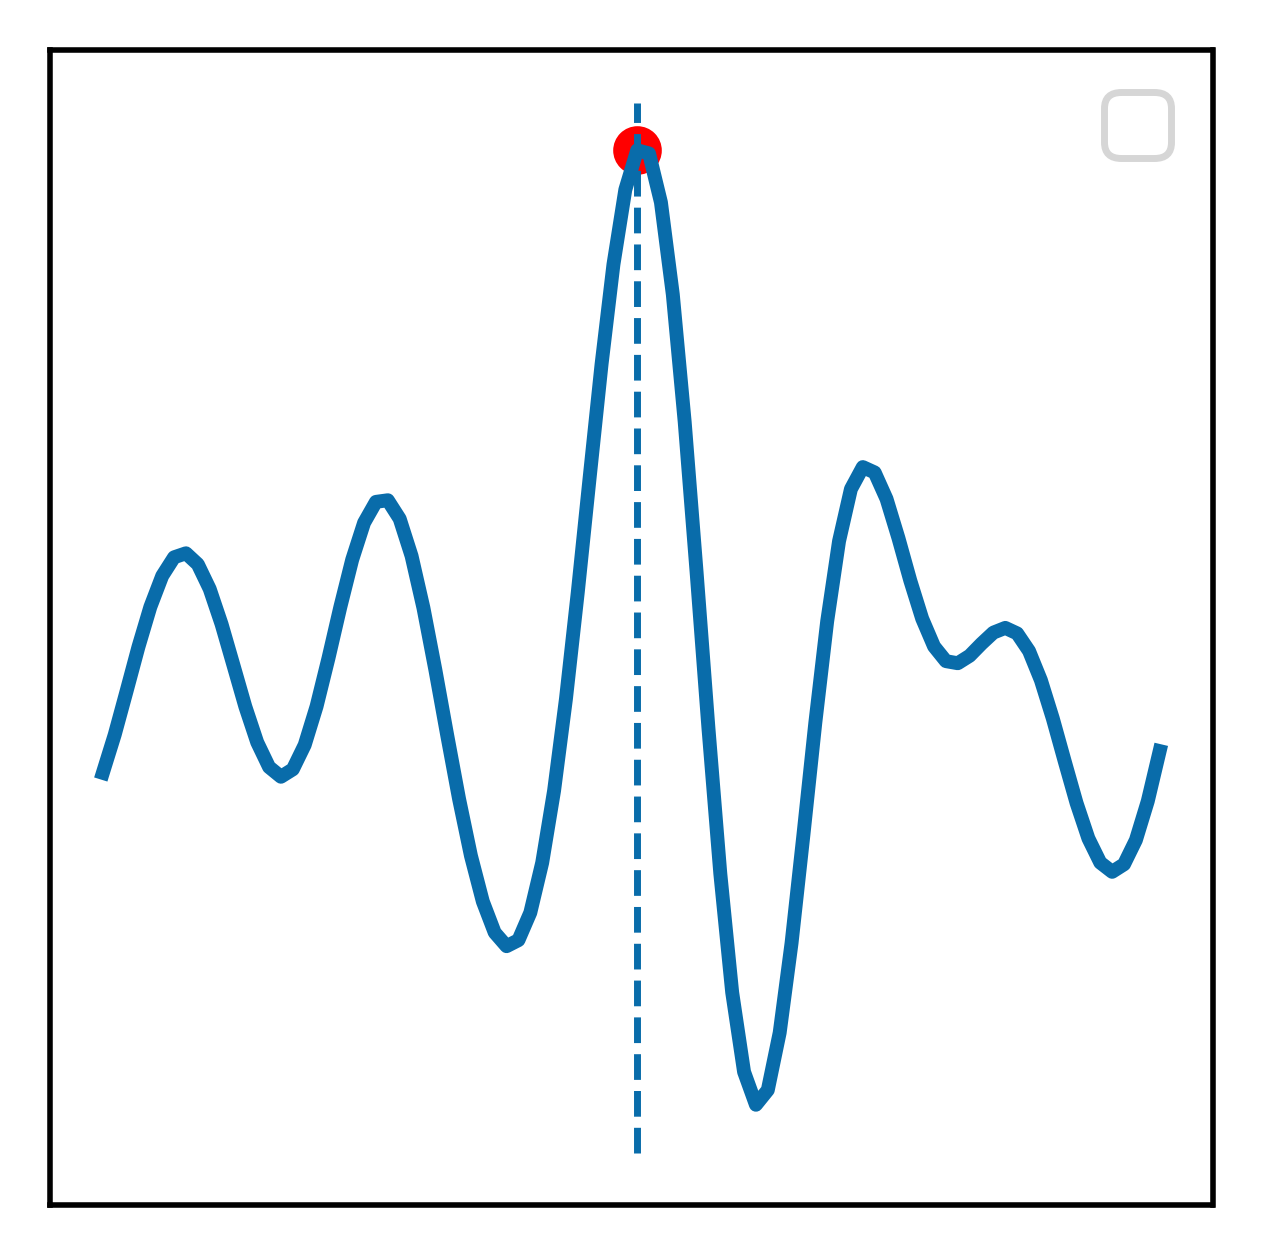

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


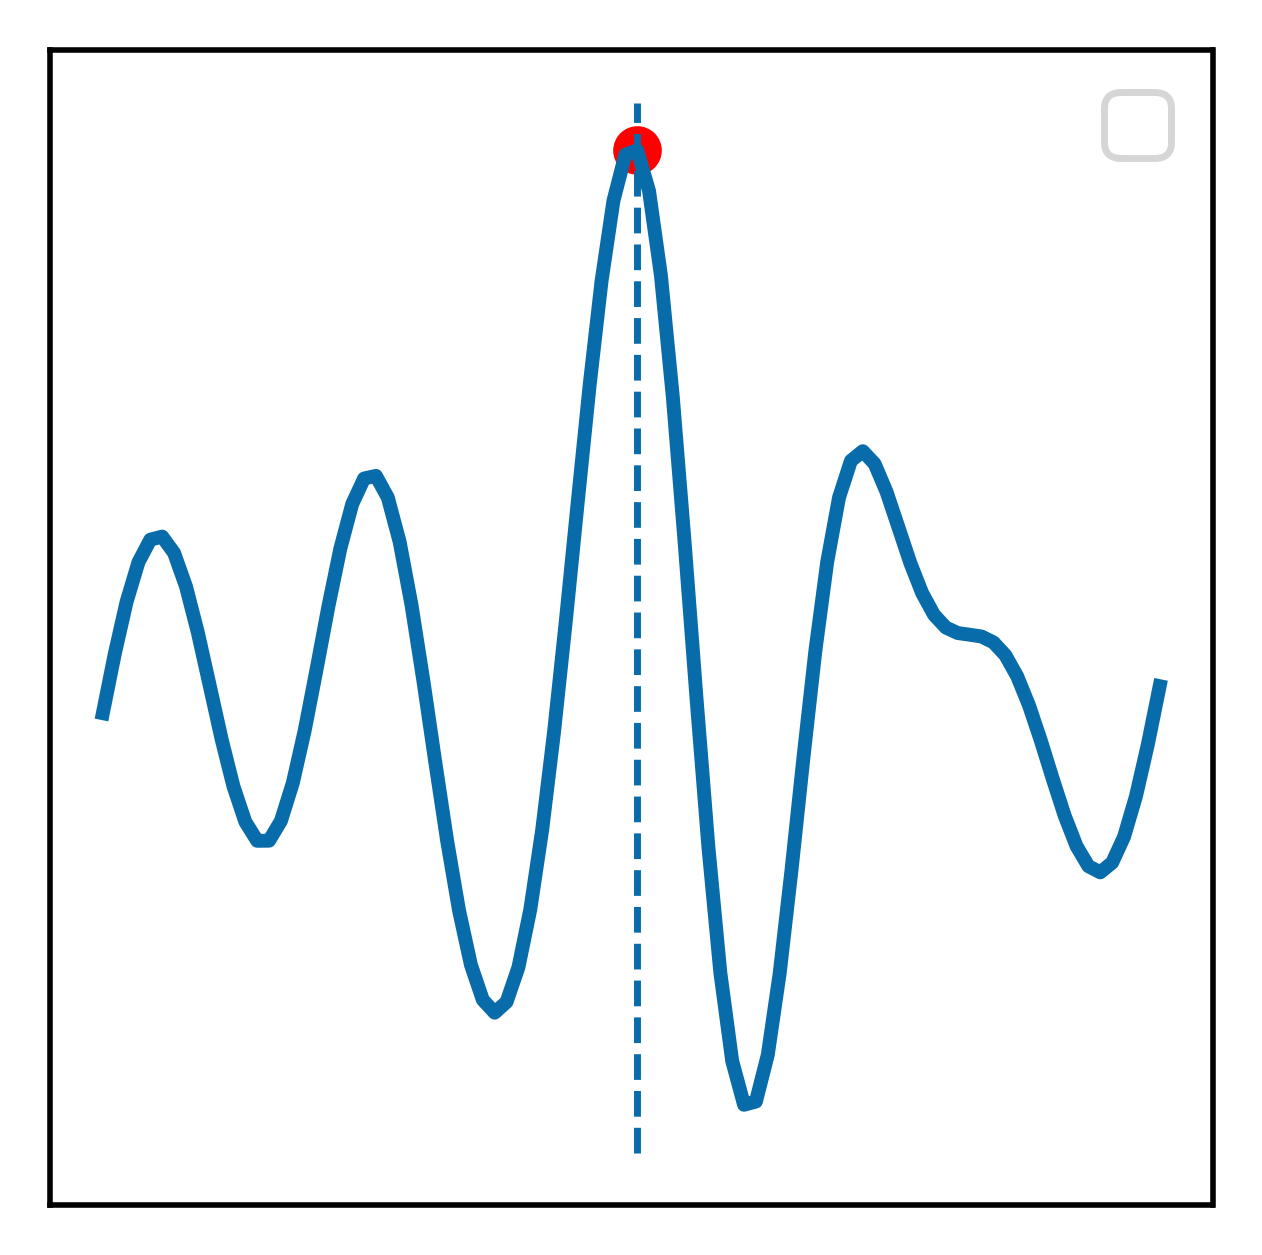

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


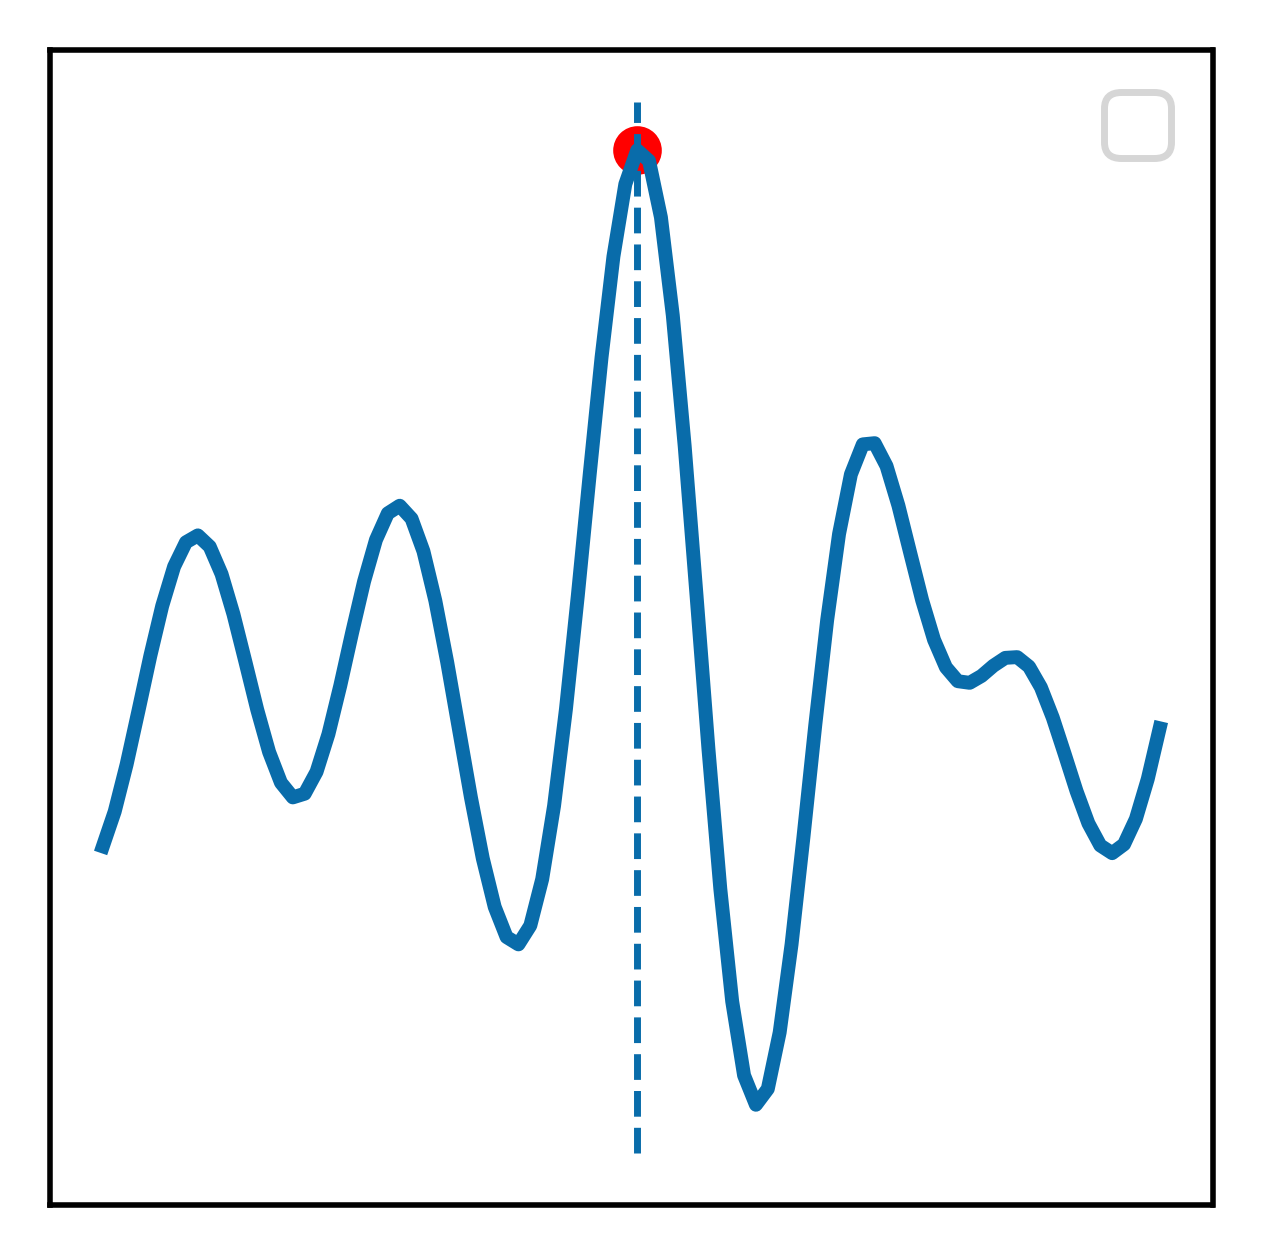

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


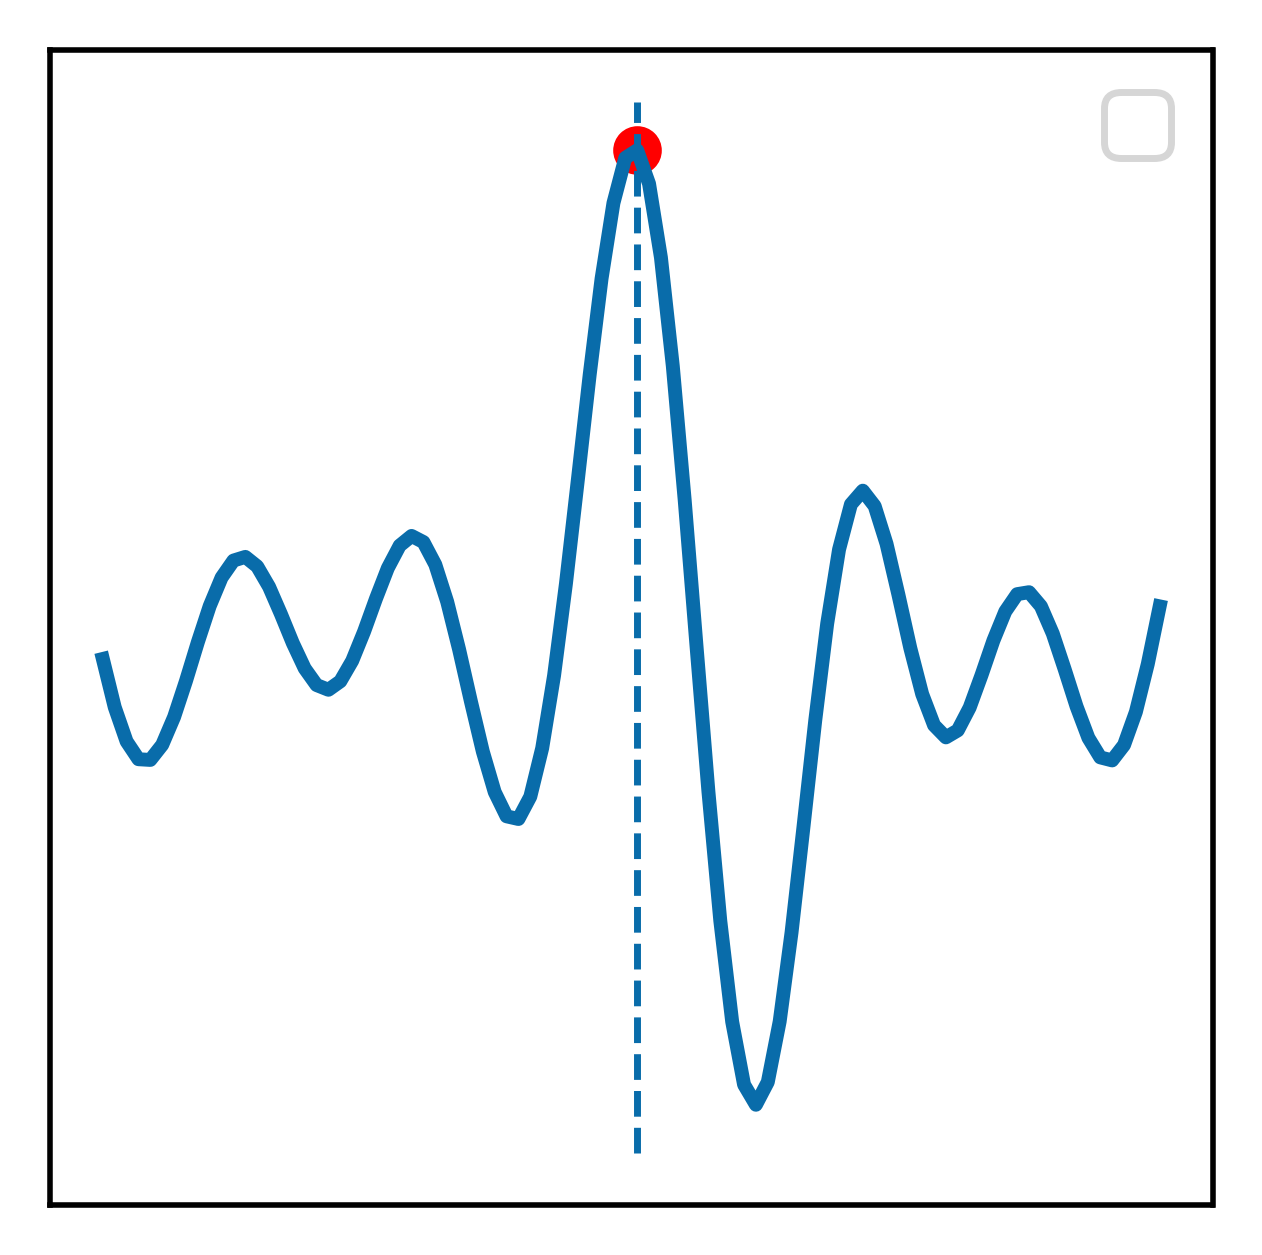

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))


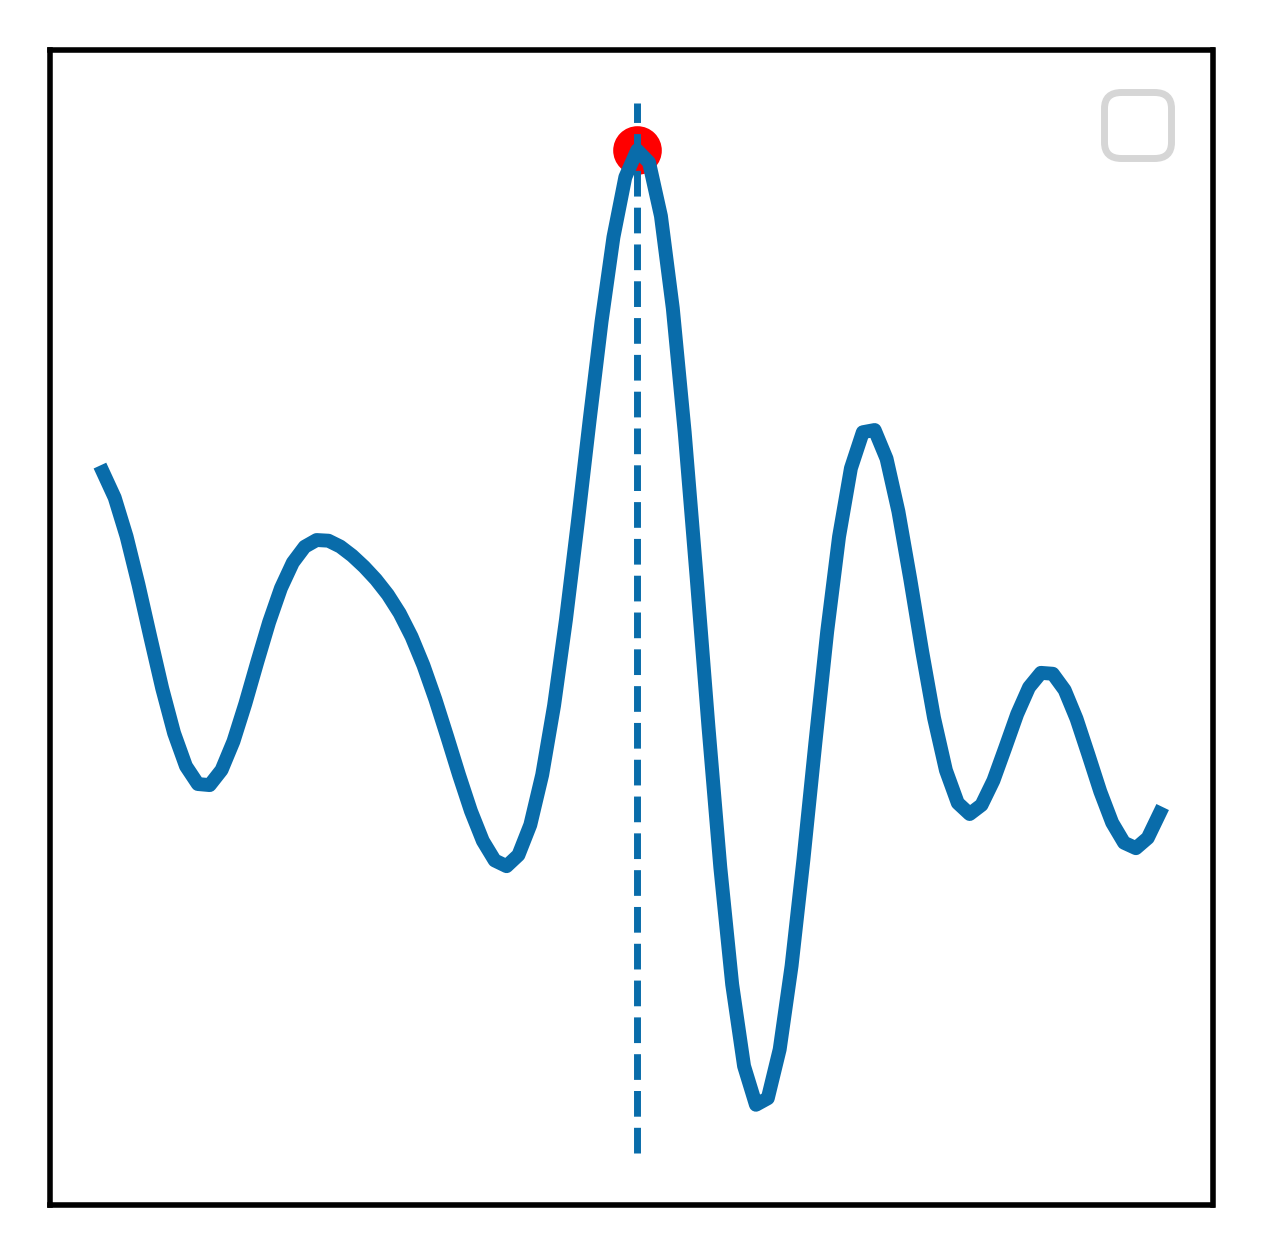

In [35]:
import numpy as np
from scipy import signal
import utils
import pandas as pd

path = r'Cross_validation/for_data/flatten_older_/LSTM_k='
k_record = [pd.read_pickle(path+str(k)+'_record.pkl') for k in range(5)]

k = 4
s = 1000
e = 1800
record = k_record[0]
flag_y = 0
flag_o = 0
for enu, (name, input, pred, label, fs_signal) in enumerate(zip(record['name'], record['input'], record['pred'], record['label'], record['fs_signal'])): 
    if enu == 0: # 1054
        pred      = pred[s:e]
        label     = label[s:e]
        input     = input[s:e]
        fs_signal = fs_signal[s:e]
        
        input = np.load(r"data_label/data_fusion/flatten/"+name+".npy")[s:e]
        # savepath = r"picture\res\\" + name
        
        input = utils.Z_ScoreNormalization(input)
        p_input = signal.find_peaks(input, distance=30, prominence=1,wlen=10)[0]
        
        fs_signal = utils.Z_ScoreNormalization(fs_signal)
        p_fs = signal.find_peaks(fs_signal, height=0.1, distance=60)[0]

        plt_plot(
            {
                'x':np.arange(e-s)/100, 'y':input, 'ylabel':'BCG','c':'#096caa',   
                'points':{'p':p_input, 'c':'red'}, 
                'vlines':{'v':p_input, 'c':"#096caa", 'lw':1},
                'hide':{'xticks':True, 'yticks':True},
                # 'rectangle':{'px':0.5,'py':-5, 'w':1.5 ,'h':10.3, 'lw':2}
                'in':{'inset':(0.25,0.05,0.1,0.4), 'section':[5,25],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
            figsize=(12, 3), linewidth=2, show=True
        )
        # 遍历 p_input 中的每个峰值点

        for idx, peak in enumerate(p_input):
            # 计算窗口起始和结束位置
            window_start = max(0, peak - 45)  # 确保不超出数据范围
            window_end = min(len(input), peak + 45)  # 确保不超出数据范围
            
            # 提取窗口数据
            window_input = input[window_start:window_end]
            window_fs = fs_signal[window_start:window_end]
            
            # 调整峰值点在窗口中的相对位置
            peak_relative = peak - window_start
            
            # 绘制该窗口的图片
            plt_plot(
                {
                    'x': np.arange(len(window_input))/100, 
                    'y': window_input, 
                    # 'ylabel': 'BCG',
                    'c': '#096caa',   
                    'points': {'p': [peak_relative], 'c': 'red'}, 
                    'vlines': {'v': [peak_relative], 'c': "#096caa", 'lw': 1},
                    'hide': {'xticks': True, 'yticks': True},
                },
                show=True, 
                figsize=(3, 3), 
                linewidth=2,
                # suptitle=f'Peak {idx+1} at position {peak}'
            )

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize'

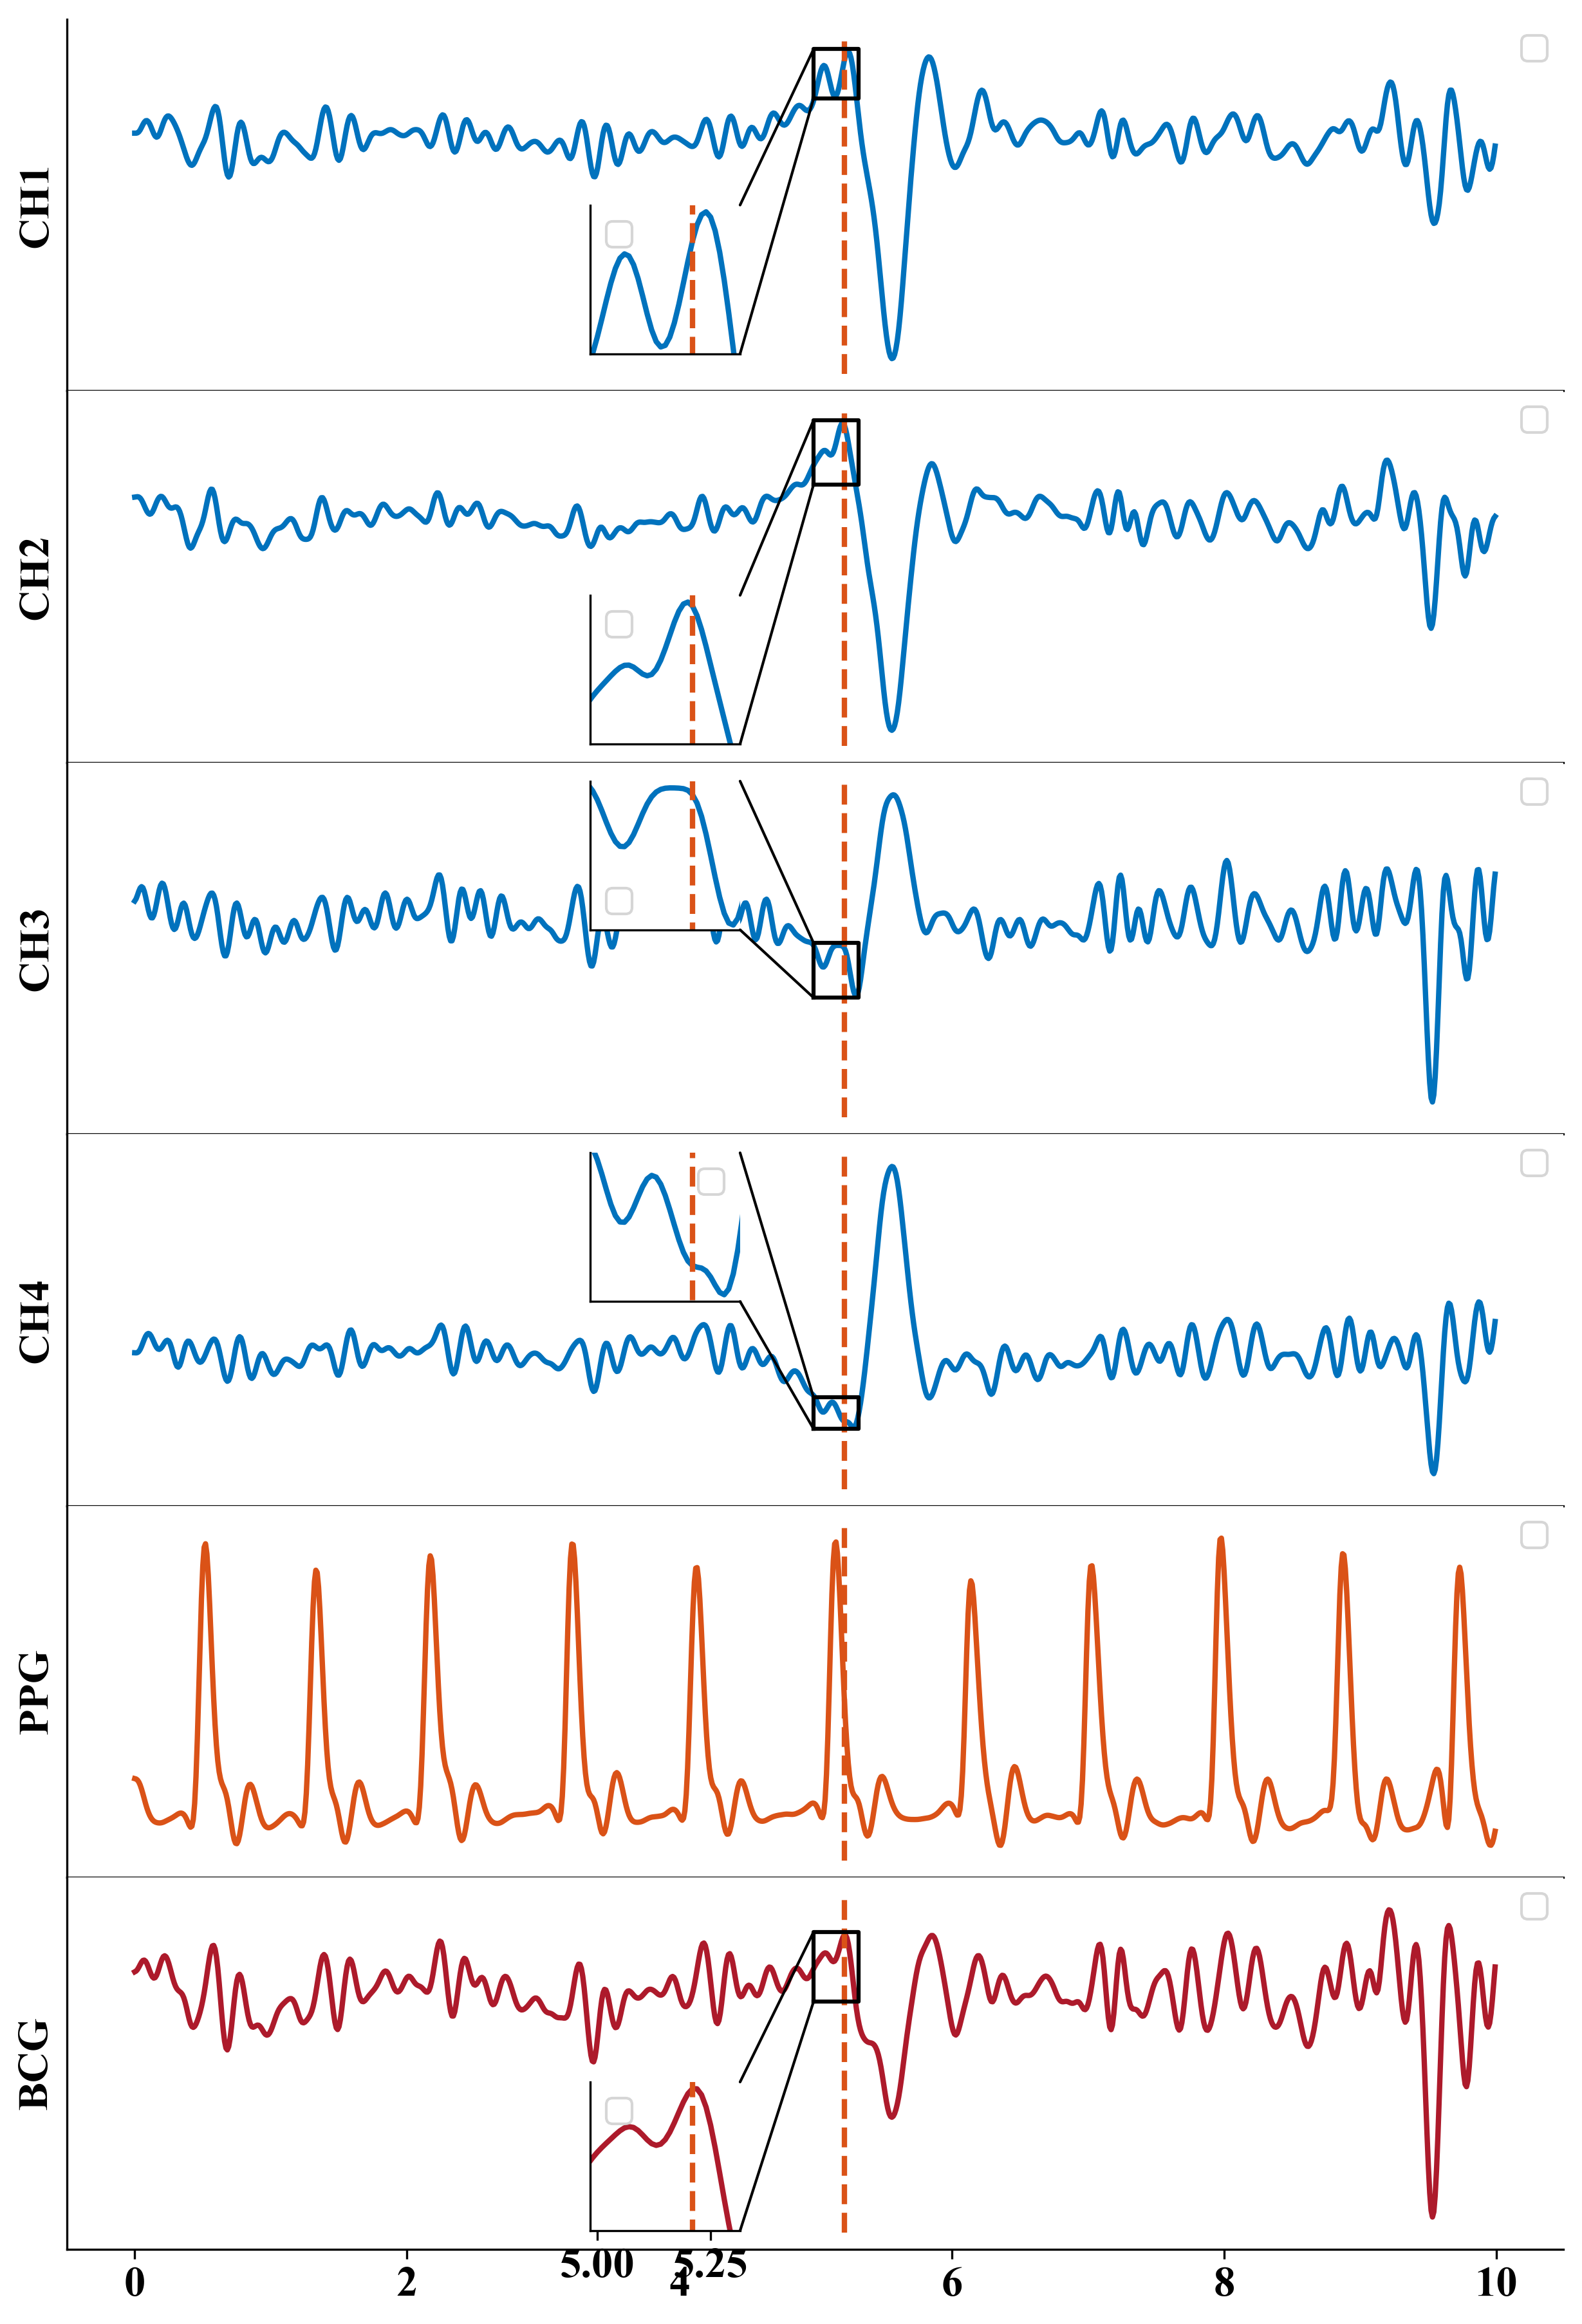

/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize', 16)-4, loc=kwargs.get('legend_loc', 'best'))
/var/folders/zz/1j0p66n9337363n5mtqryxkw0000gn/T/ipykernel_58529/1074458143.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=kwargs.get('legend_fontsize'

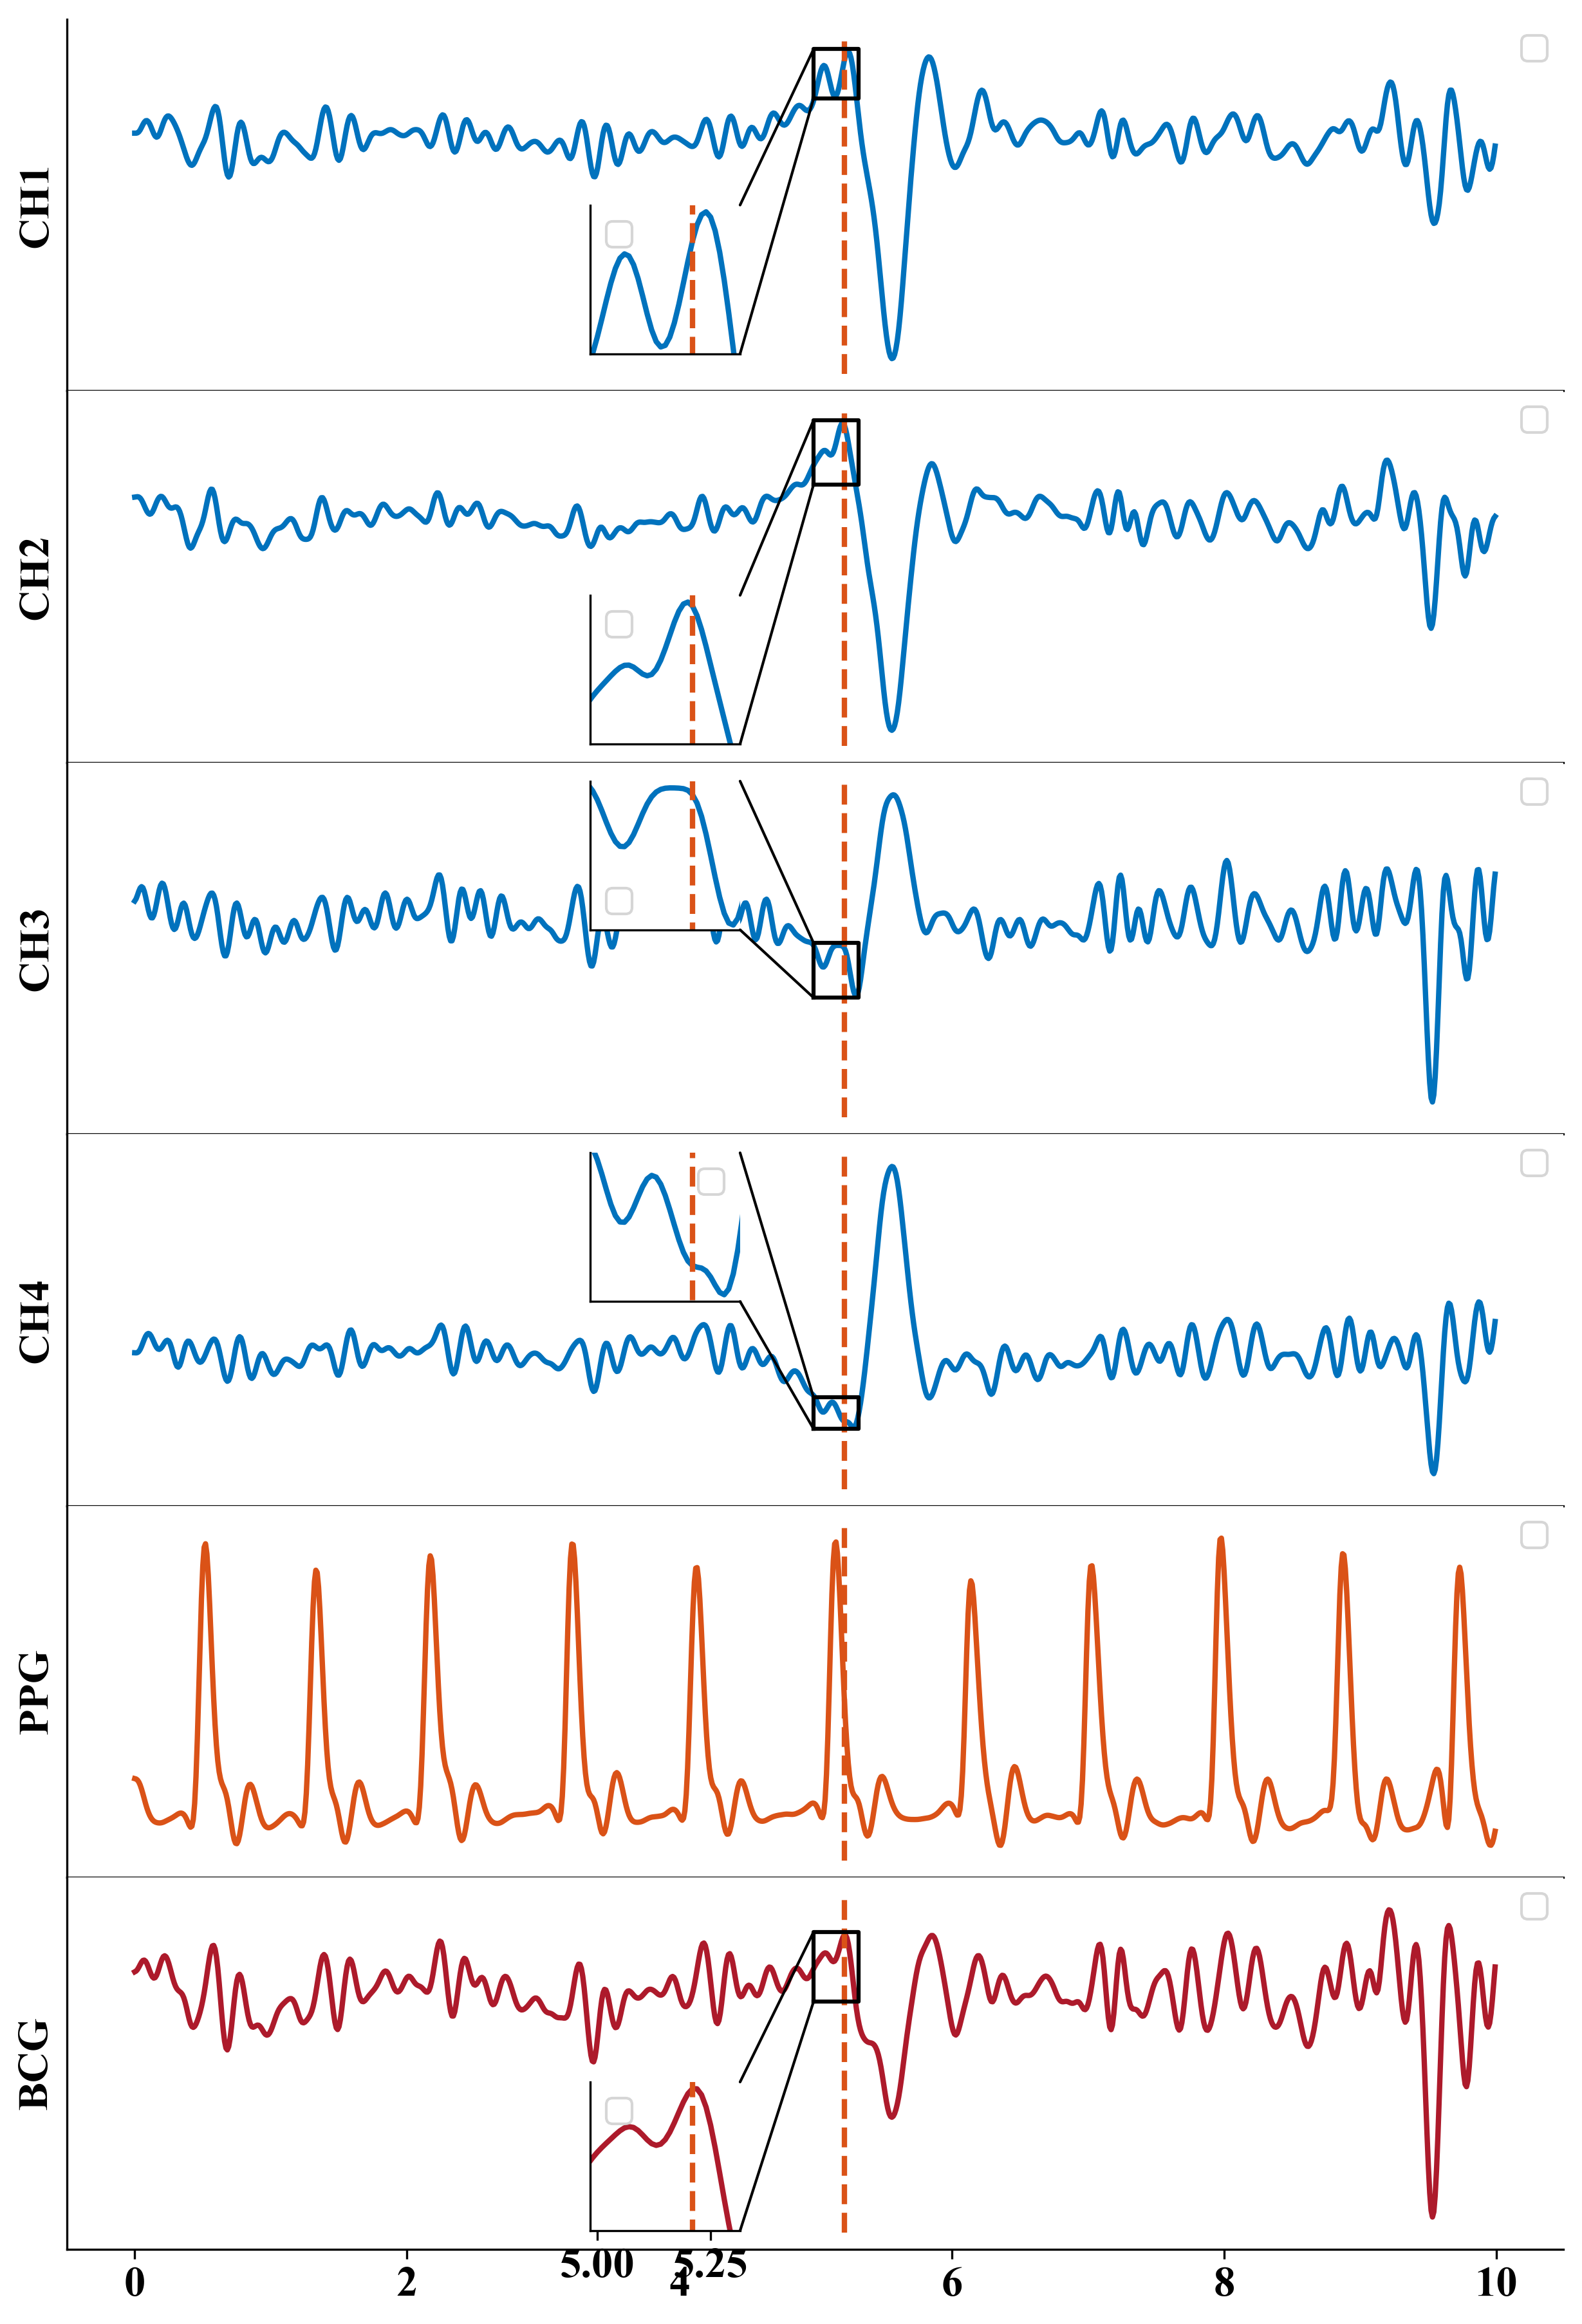

In [4]:
import numpy as np
import glob
import re

from scipy import io


categories = ['flatten', 'older']
res_dic = {'name':[], 'bcg':[], 'fs':[]}

name_all = []
for category in categories[:]:
    fs_glob = glob.glob(r"data_label/data_original/flatten/BCG/*_fs.mat")
    list_name = []
    for fs in fs_glob:
        name = re.findall(r"\d+", fs)[0]
        list_name.append(name)
        res_dic['name'].append(name)
        
    length = 1500
    sampling_rate = 100
    for name in list_name:
        bcg = r"data_label/data_original/flatten/BCG/BCG_" + name + ".mat"
        fs = r"data_label/data_original/flatten/BCG/" + name + "_fs.mat"
        # print(name)
        name_all.append(name)
        # name = os.path.split(bcg)[-1]
        # name = os.path.splitext(name)[0]

        bcg_mat = io.loadmat(bcg)
        BCG_f = bcg_mat["BCG_f"]

        fs_mat = io.loadmat(fs)
        FS_f = fs_mat["FS_f"]

        data_bcg = [[], [], [], []]
        data_bcg[0] = BCG_f[:, 0]
        data_bcg[1] = BCG_f[:, 1]
        data_bcg[2] = BCG_f[:, 2]
        data_bcg[3] = BCG_f[:, 3]

        data_fs = FS_f[:, 0]
        
        res_dic["bcg"].append(data_bcg)
        res_dic["fs"].append(data_fs)
pass


sampling_rate = 100
length = sampling_rate * 10
s = 0
e = 1000
__name = '1024'

# for id in range(13,14):
for id, name in enumerate(name_all):
    if name != __name:
        continue
    # 'points':{'p':p_fs, 'c':'red'},
    # 'vlines':{'v':p_fs, 'c':"#09986e", 'lw':1},
    # 'hide':{'yticks':True, 't': True},
    bcg_con = res_dic["bcg"][id][0][s:e]+res_dic["bcg"][id][1][s:e]+res_dic["bcg"][id][2][s:e]+res_dic["bcg"][id][3][s:e]
    plt_plot(
                {
                    'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][0][s:e], 'ylabel':'CH1', 'c':'#0072bd',
                    'hide':{'xticks':True, 'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                    'in':{'inset':(0.35,0.1,0.1,0.4), 'section':[500, 530],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
                {
                    'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][1][s:e], 'ylabel':'CH2', 'c':'#0072bd',
                    'hide':{'xticks':True, 'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                    'in':{'inset':(0.35,0.05,0.1,0.4), 'section':[500, 530],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
                {
                    'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][2][s:e], 'ylabel':'CH3', 'c':'#0072bd',
                    'hide':{'xticks':True, 'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                    'in':{'inset':(0.35,0.55,0.1,0.4), 'section':[500, 530],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
                {
                    'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][3][s:e], 'ylabel':'CH4', 'c':'#0072bd',
                    'hide':{'xticks':True, 'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                    'in':{'inset':(0.35,0.55,0.1,0.4), 'section':[500, 530],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
                
                {
                    'x':np.arange(length) / sampling_rate, 'y':res_dic["fs"][id][s:e]    , 'ylabel':'PPG',   'c':'#da5217', 
                    'hide':{'xticks':True, 'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                },
                
                {
                    'x':np.arange(length) / sampling_rate, 'y':bcg_con, 'ylabel':'BCG', 'c':'#ad1a2b',
                    'hide':{'yticks':True, 't': True,  'r': True},
                    'vlines':{'v':521, 'c':"#da5217", 'lw':2},
                    'in':{'inset':(0.35,0.05,0.1,0.4), 'section':[500, 530],'location':'left', 'hide':{'xticks':True, 'yticks':True}}
                },
                # {'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][1][s:e], 'ylabel':'CH2', 'c':'#0072bd', 'hide_yticks':True, 'hide_xticks':True, 'hide_top_right': True, 'vlines':521, 'vlines_color':'#da5217', 'vlines_linewidth':2, 'in':{'inset':(0.35,0.1,0.1,0.4), 'section':[500, 530], 'hide_yticks':True, 'hide_xticks':True, 'location':'left'}},
                # {'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][2][s:e], 'ylabel':'CH3', 'c':'#0072bd', 'hide_yticks':True, 'hide_xticks':True, 'hide_top_right': True, 'vlines':521, 'vlines_color':'#da5217', 'vlines_linewidth':2, 'in':{'inset':(0.35,0.05,0.1,0.4), 'section':[500, 530], 'hide_yticks':True, 'hide_xticks':True, 'location':'left'}}, 
                # {'x':np.arange(length) / sampling_rate, 'y':res_dic["bcg"][id][3][s:e], 'ylabel':'CH4', 'c':'#0072bd', 'hide_yticks':True, 'hide_xticks':True, 'hide_top_right': True, 'vlines':521, 'vlines_color':'#da5217', 'vlines_linewidth':2, 'in':{'inset':(0.35,0.55,0.1,0.4), 'section':[500, 530], 'hide_yticks':True, 'hide_xticks':True, 'location':'left'}},
                # {'x':np.arange(length) / sampling_rate, 'y':res_dic["fs"][id][s:e]    , 'ylabel':'PPG',   'c':'#da5217', 'hide_yticks':True, 'hide_xticks':True, 'hide_top_right': True, 'vlines':521, 'vlines_color':'#da5217', 'vlines_linewidth':2, },
                # {'x':np.arange(length) / sampling_rate, 'y':bcg_con                       , 'ylabel':'BCG',   'c':'#b1182c', 'hide_yticks':True, 'xlabel':"Time (s)",'hide_top_right': True, 'vlines':521, 'vlines_color':'#da5217', 'vlines_linewidth':2, 'in':{'inset':(0.35,0.05,0.1,0.4), 'section':[500, 530], 'hide_yticks':True, 'hide_xticks':True, 'location':'left'}},
                text=True, figsize = (10, 15), dpi=300, hspace=0
            )
